# Projet DATA SCIENCE - Analyse du Churn Client
Ce notebook suit une demarche de data analyste: exploration, preparation des donnees, modelisation et comparaison des performances.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder


In [2]:
df_temp = pd.read_csv('customer_churn_business_dataset.csv')

df = df_temp.drop("customer_id", axis="columns")
df.head(10)


,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,weekly_active_days,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,7,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,5,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,Male,24,Germany,New York,SME,58,Web,Yearly,19,5,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,7,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,6,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0
5,Female,36,India,London,Individual,54,Mobile,Monthly,1,3,...,36.038391,Technical,4.0,1,0.83,0.05,-40,Neutral,1,0
6,Male,23,India,Toronto,SME,54,Mobile,Monthly,21,4,...,36.892928,Billing,4.0,0,0.75,0.46,-3,Neutral,1,0
7,Male,37,Bangladesh,Sydney,Individual,7,Referral,Yearly,17,7,...,25.024133,Technical,4.0,1,0.54,0.13,28,Satisfied,1,0
8,Male,44,India,Delhi,SME,15,Referral,Monthly,29,4,...,32.465536,Technical,2.0,0,0.85,0.13,-24,Satisfied,0,0
9,Female,70,Bangladesh,Berlin,Individual,17,Mobile,Monthly,18,5,...,42.986192,Billing,4.0,0,0.72,0.13,17,Neutral,1,0


In [3]:
df.describe()


,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,avg_resolution_time,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000
mean,45.906100,30.155700,19.672000,3.479400,15.187890,4.990800,0.019423,9.505200,34.930000,1057.018000,0.501000,1.206600,23.953210,3.486700,0.294100,0.499610,0.253575,19.110500,0.9922,0.102100
std,16.420416,17.099517,9.838003,2.302283,6.830774,2.211607,0.149567,9.799417,23.785115,1020.148233,0.711934,1.104554,9.956999,0.978631,0.543171,0.231601,0.140532,38.936619,0.9939,0.302795
min,18.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-0.580000,0.000000,10.000000,10.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.100000,0.010000,-100.000000,0.0000,0.000000
25%,32.000000,16.000000,13.000000,1.000000,10.391645,3.000000,-0.080000,2.000000,20.000000,340.000000,0.000000,0.000000,17.082041,3.000000,0.000000,0.300000,0.130000,-7.000000,0.0000,0.000000
50%,46.000000,30.000000,20.000000,3.000000,15.161659,5.000000,0.020000,6.000000,30.000000,720.000000,0.000000,1.000000,23.950444,4.000000,0.000000,0.500000,0.250000,19.000000,1.0000,0.000000
75%,60.000000,45.000000,26.000000,5.000000,19.882034,6.000000,0.120000,13.000000,50.000000,1440.000000,1.000000,2.000000,30.758480,4.000000,1.000000,0.700000,0.380000,46.000000,2.0000,0.000000
max,74.000000,59.000000,54.000000,7.000000,41.996411,15.000000,0.540000,80.000000,100.000000,5900.000000,5.000000,7.000000,61.821878,5.000000,4.000000,0.900000,0.500000,100.000000,7.0000,1.000000


In [4]:
print(f"Dimensions du dataset :(lignes, clonnes) {df.shape}")
print()

audit_df = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_values': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2)
}).sort_values(by='missing_values', ascending=False)

display(audit_df.head(15))


Dimensions du dataset :(lignes, clonnes) (10000, 31)



,dtype,missing_values,missing_pct
complaint_type,object,2045,20.45
age,int64,0,0.00
gender,object,0,0.00
city,object,0,0.00
customer_segment,object,0,0.00
tenure_months,int64,0,0.00
country,object,0,0.00
contract_type,object,0,0.00
monthly_logins,int64,0,0.00
weekly_active_days,int64,0,0.00


On peut voir que on a dans complaint_type des valeurs manquantes, ou peut etre pas puisque sont juste le categorie.

In [5]:
df_corr = df.copy()

label_encoder = LabelEncoder()

for col in df_corr.select_dtypes(include=["object"]).columns:
    df_corr[col] = label_encoder.fit_transform(df_corr[col].astype(str))

df_corr.head()


,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,weekly_active_days,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,1,68,1,3,2,22,2,0,26,7,...,13.354360,1,4.0,0,0.71,0.40,27,1,1,0
1,0,57,2,5,1,9,0,0,7,5,...,25.140088,0,2.0,0,0.78,0.33,-19,0,2,1
2,1,24,3,4,2,58,2,2,19,5,...,27.572928,1,3.0,0,0.35,0.49,80,0,1,0
3,1,49,0,2,1,19,0,2,34,7,...,26.420822,2,5.0,1,0.83,0.15,100,0,0,0
4,1,65,1,1,1,52,2,0,20,6,...,26.674579,2,4.0,0,0.65,0.44,21,2,1,0


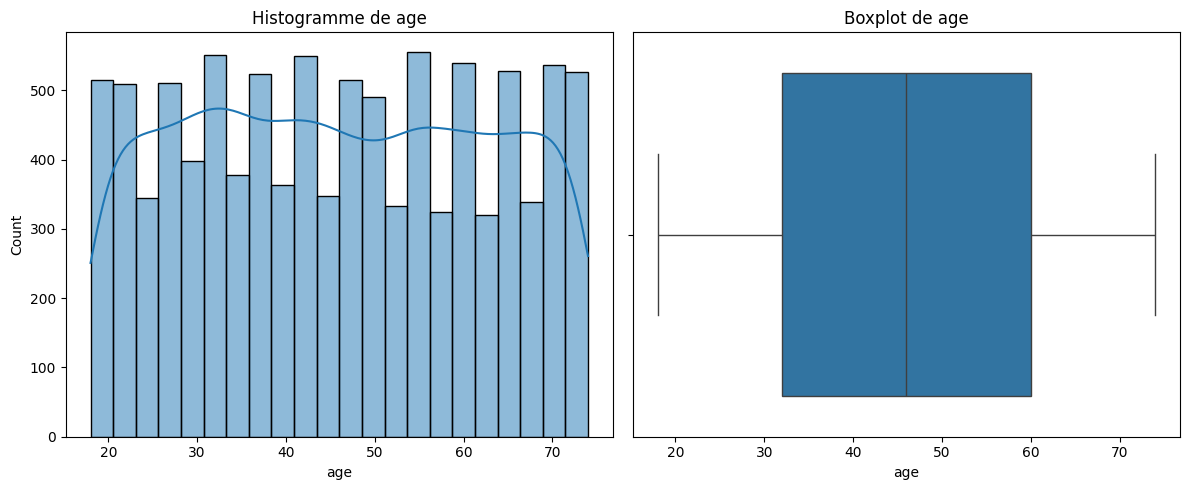

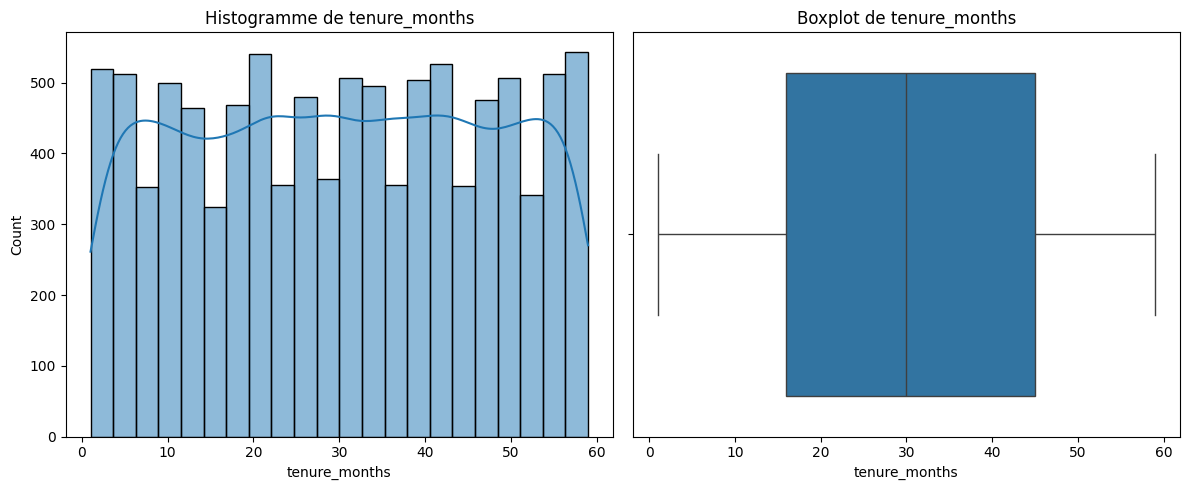

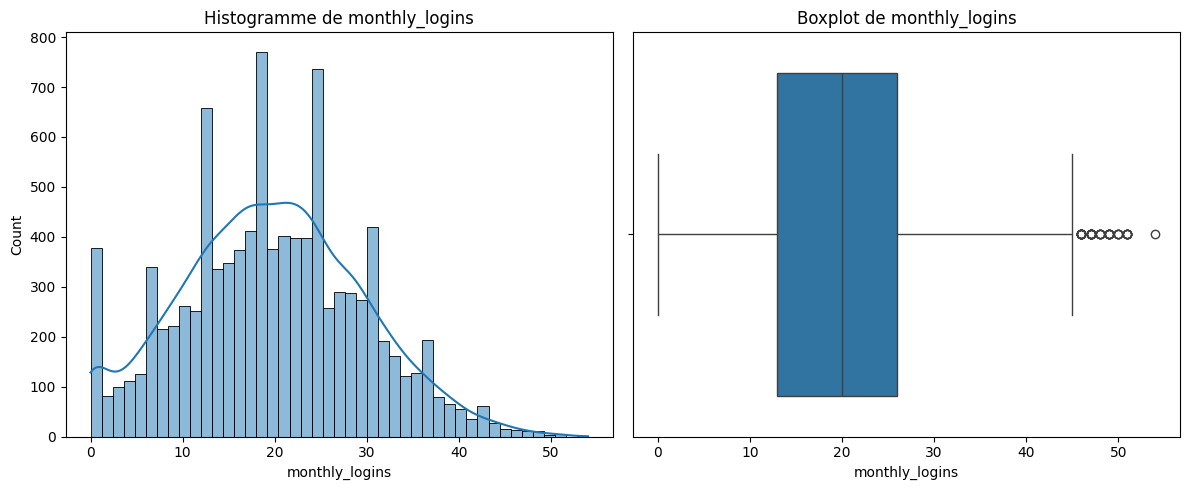

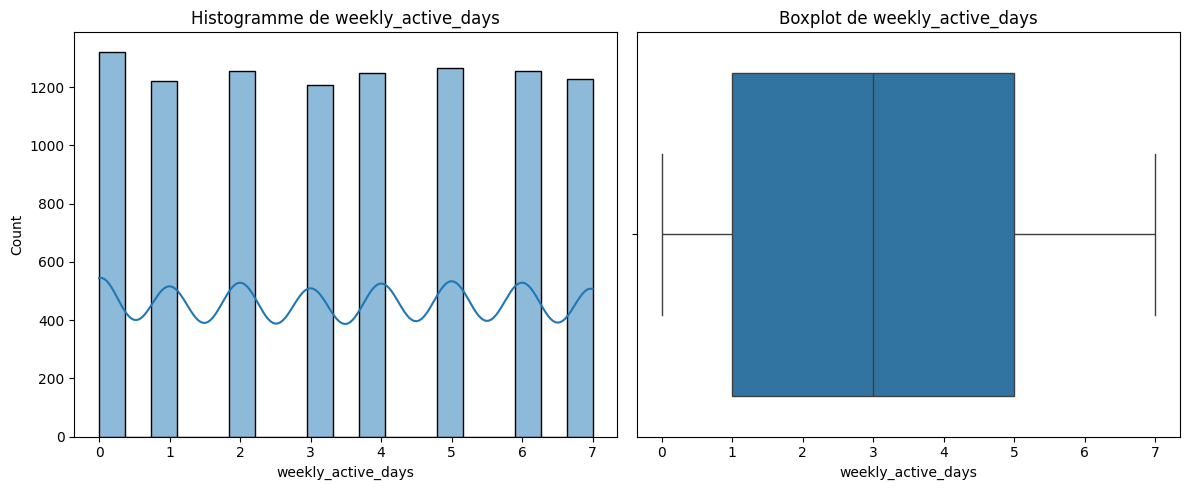

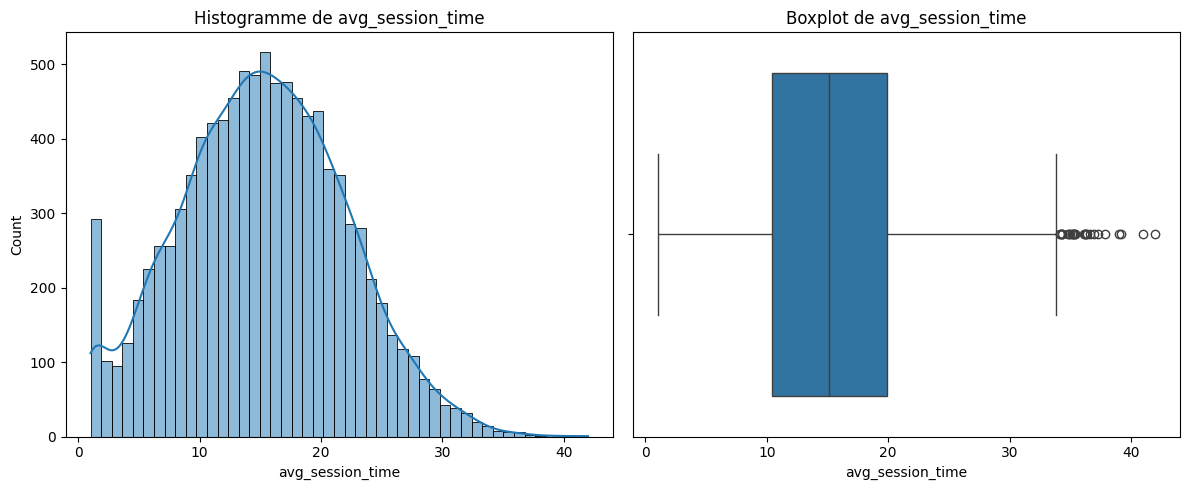

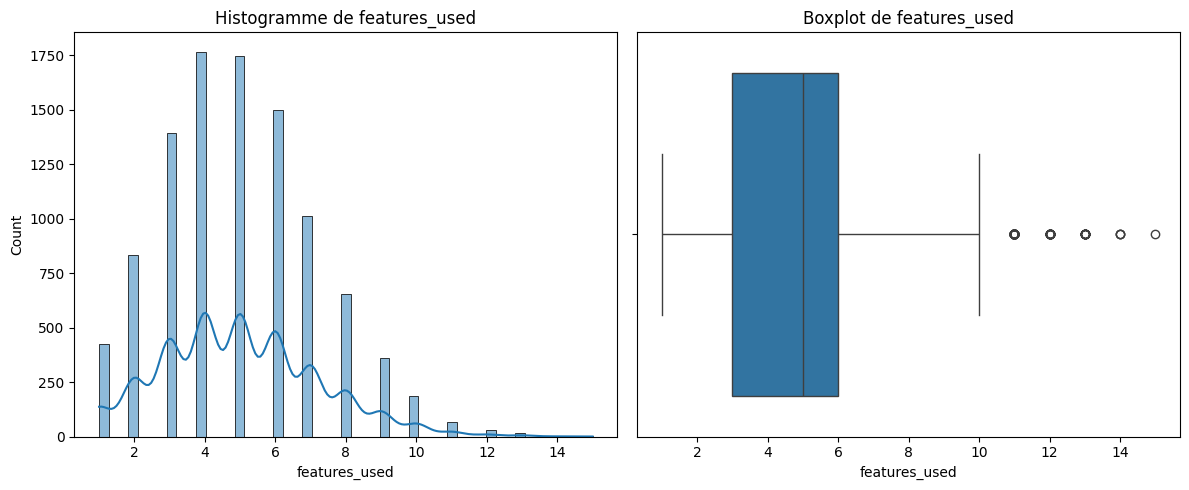

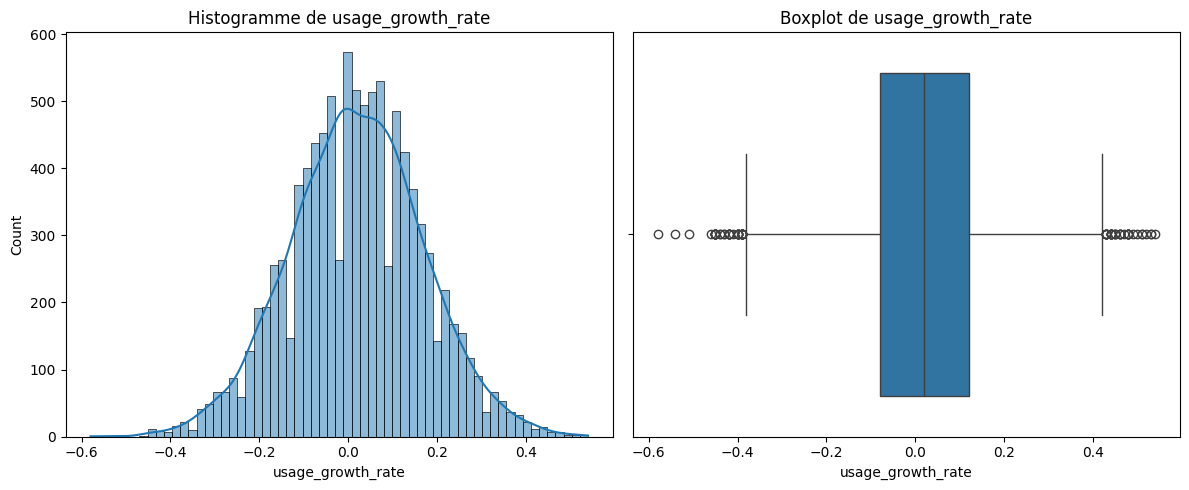

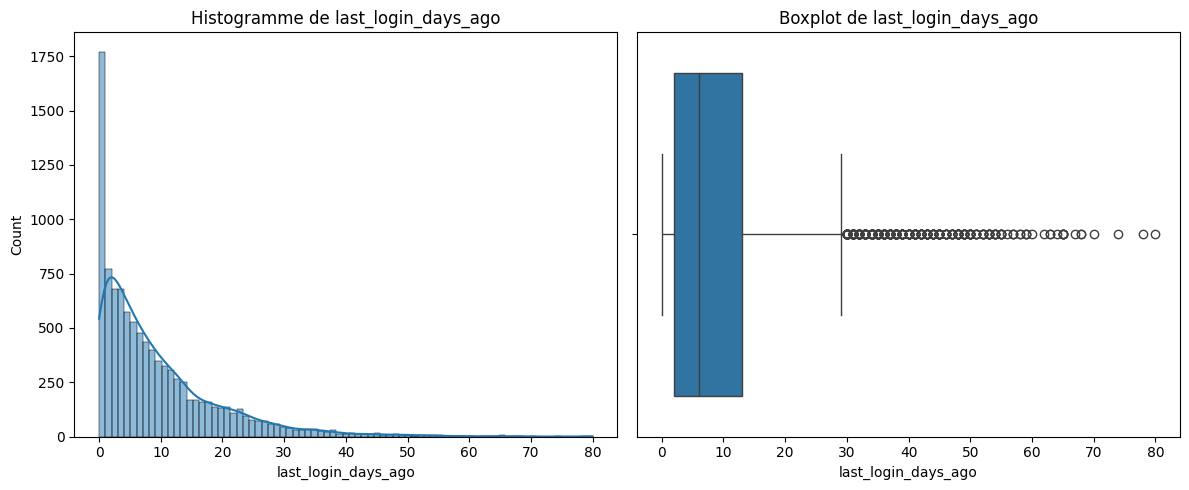

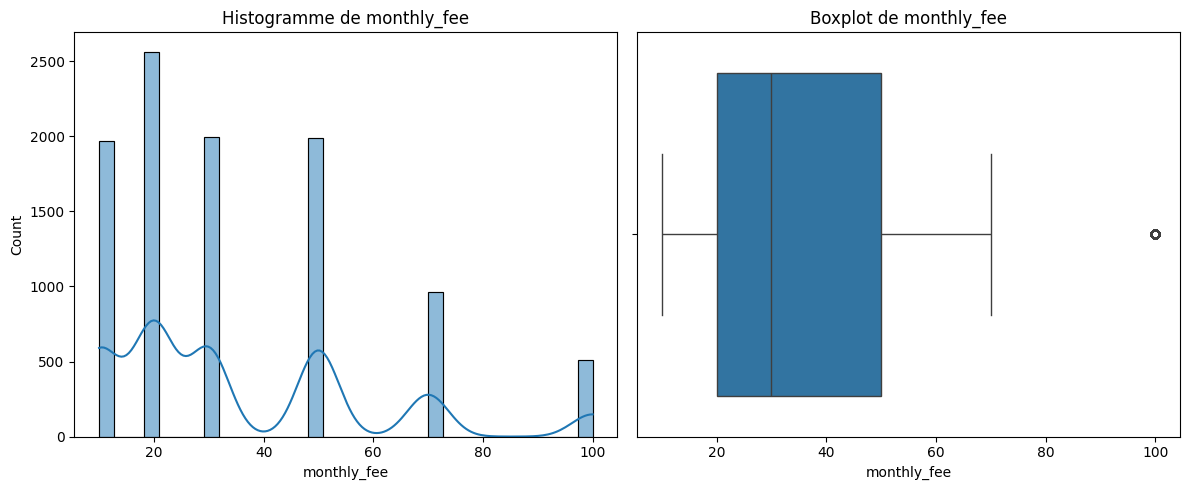

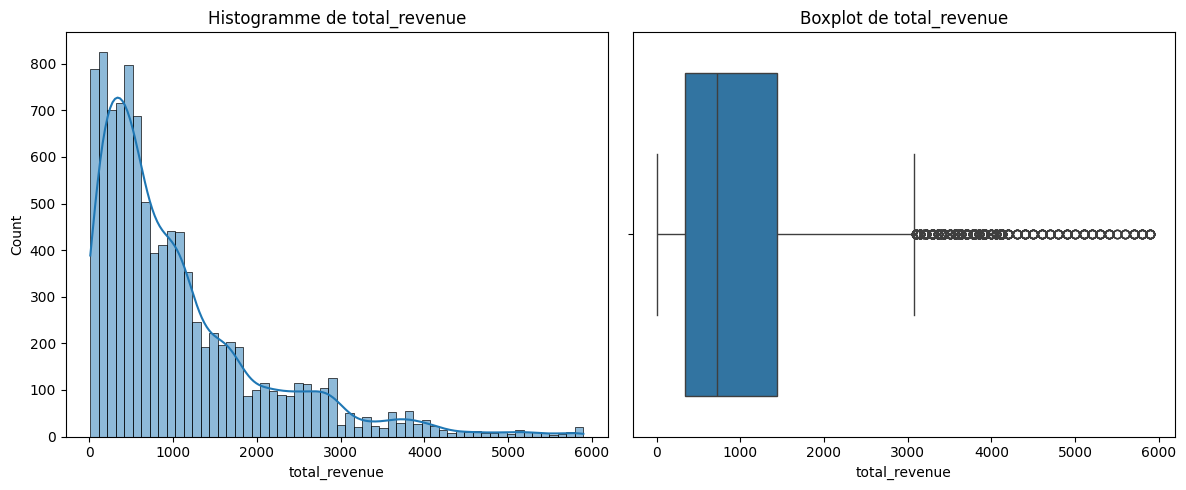

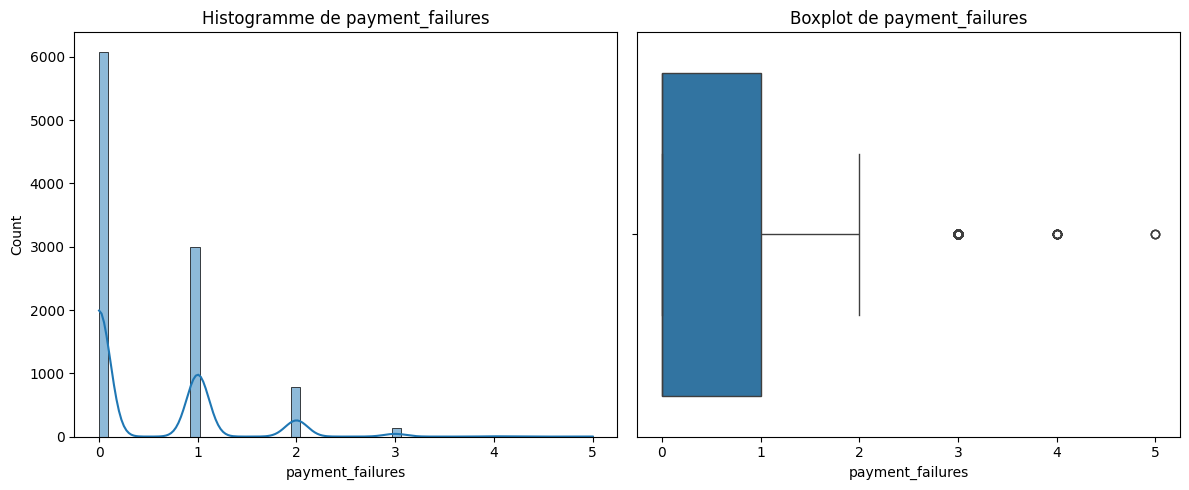

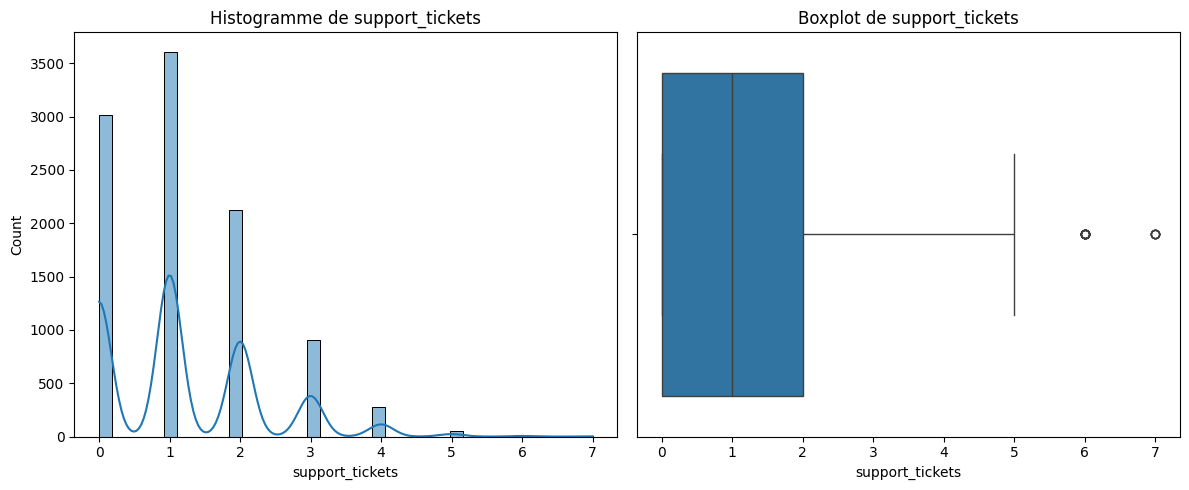

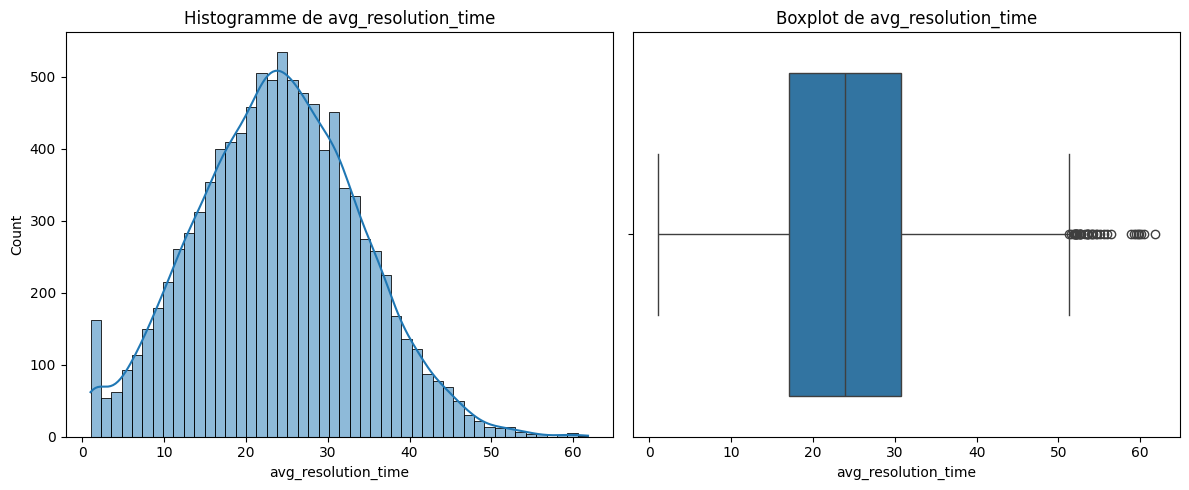

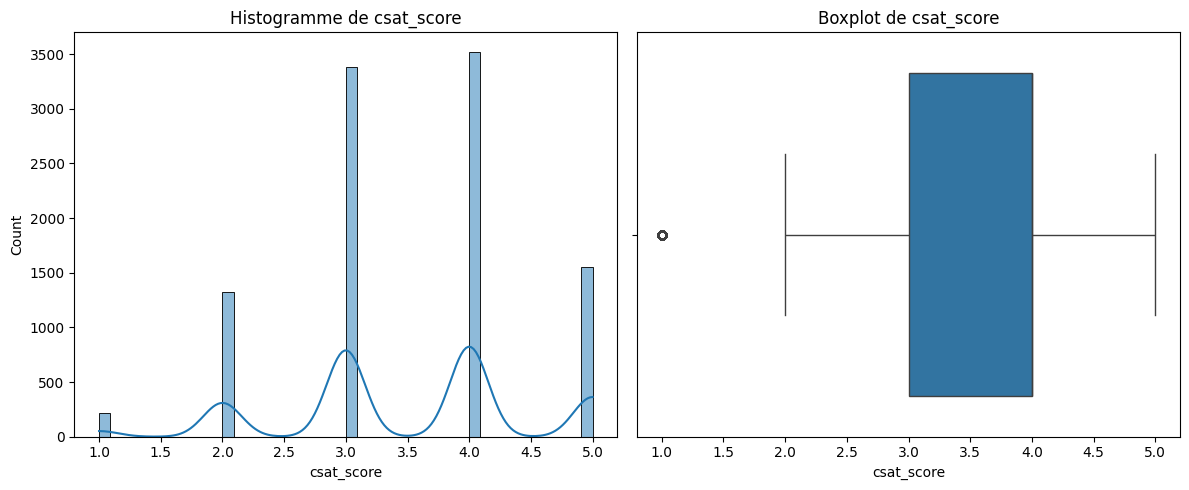

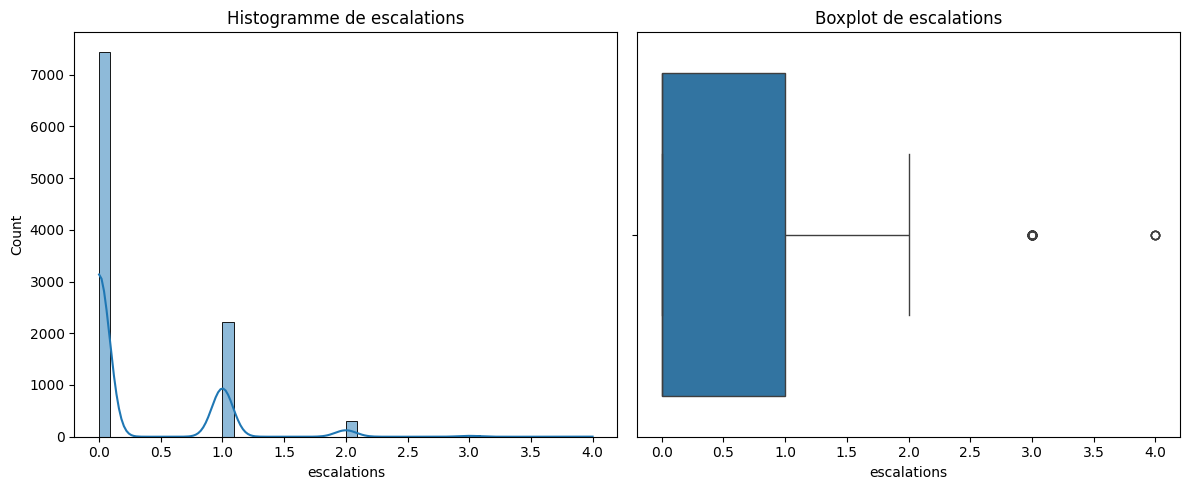

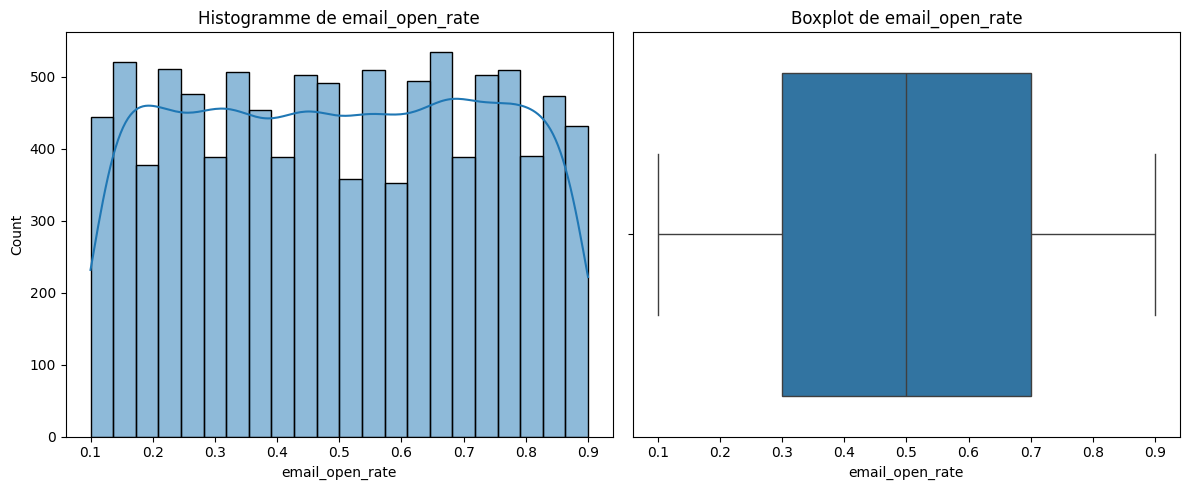

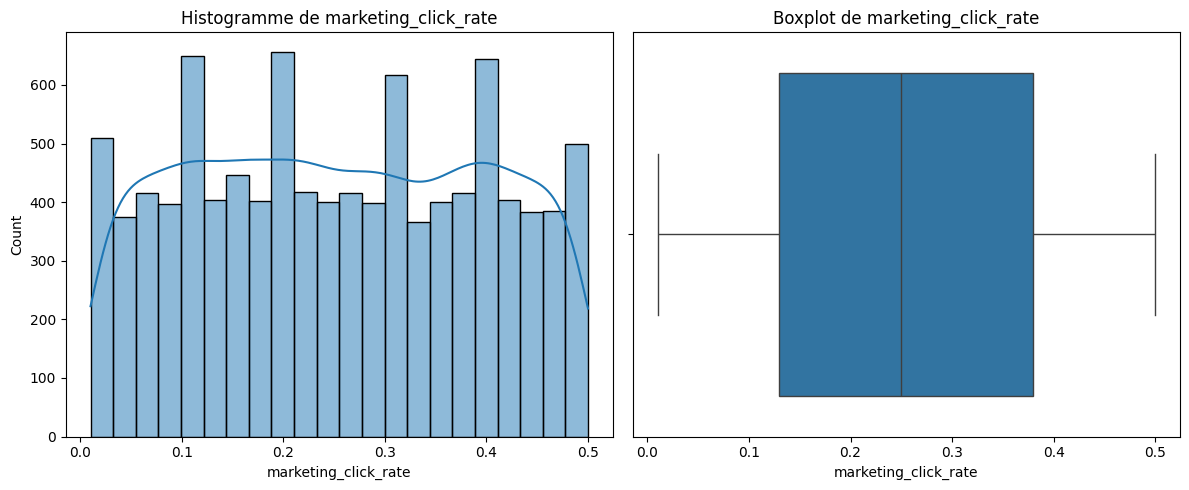

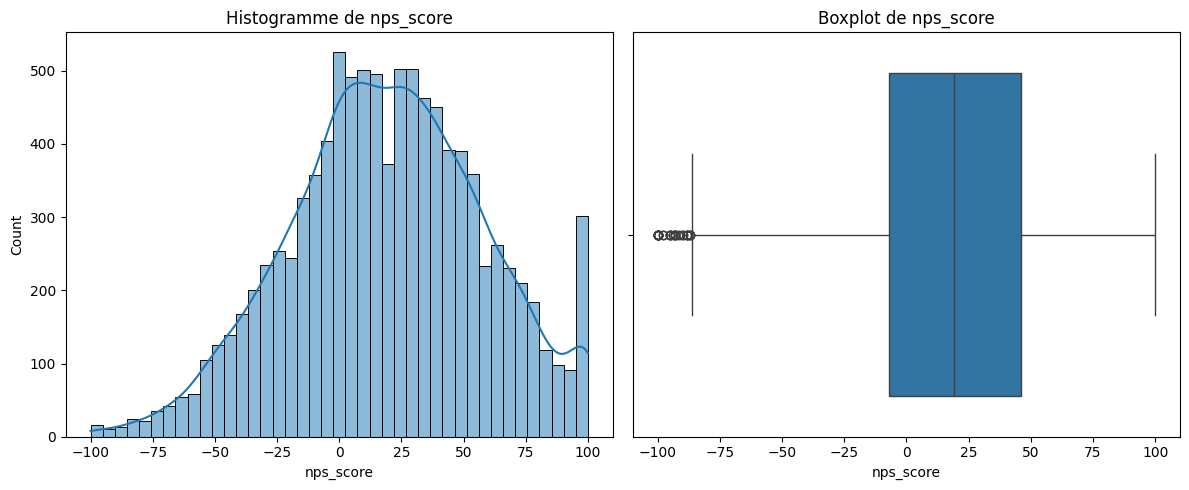

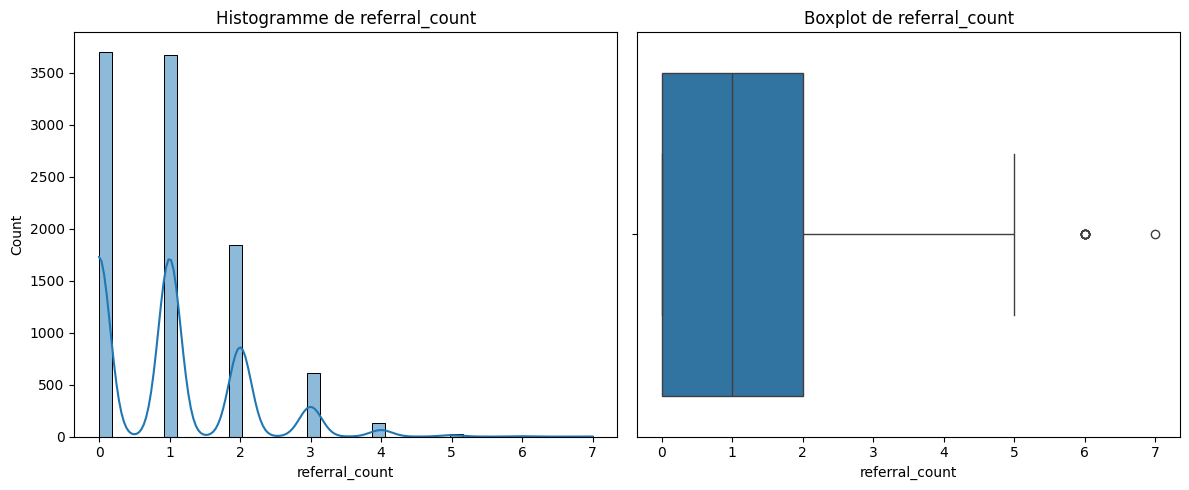

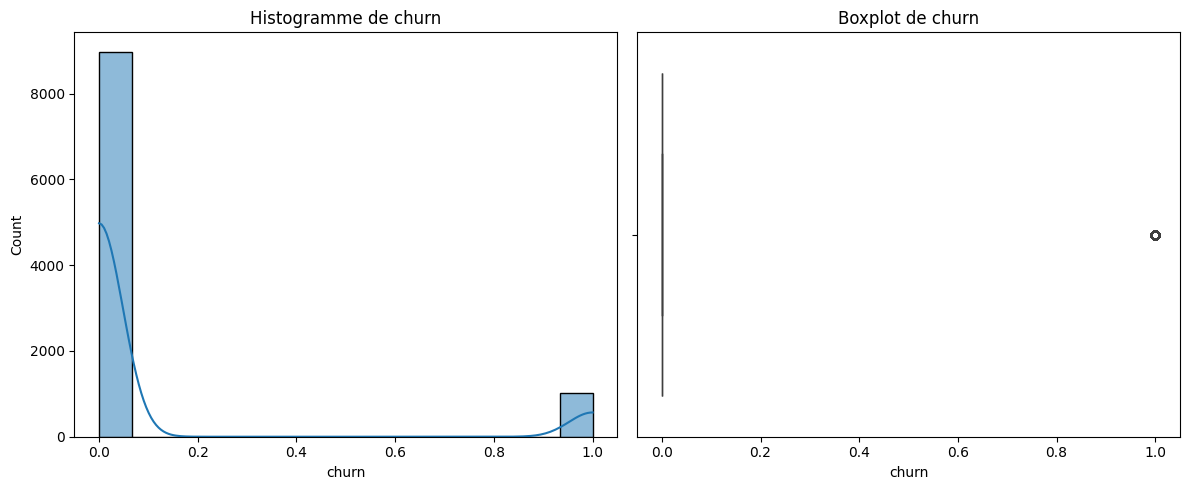

In [6]:
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogramme de {col}')
    
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    
    plt.tight_layout()
    plt.show()


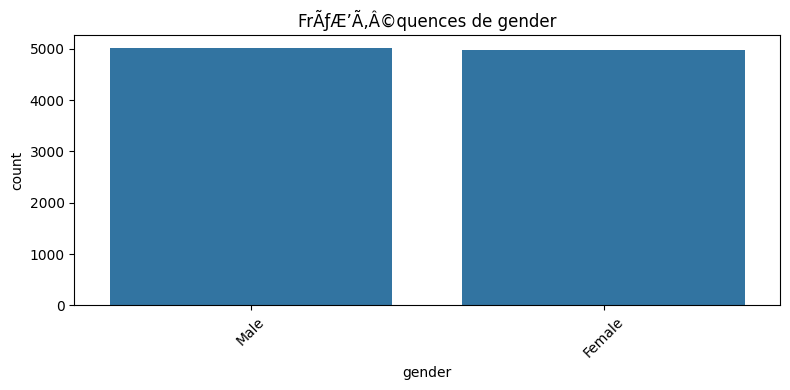

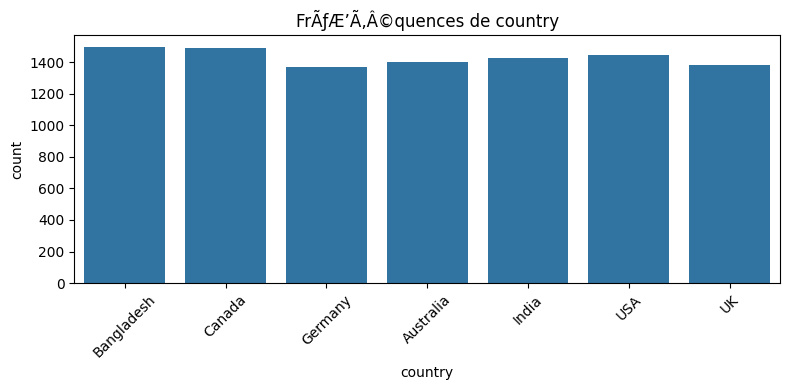

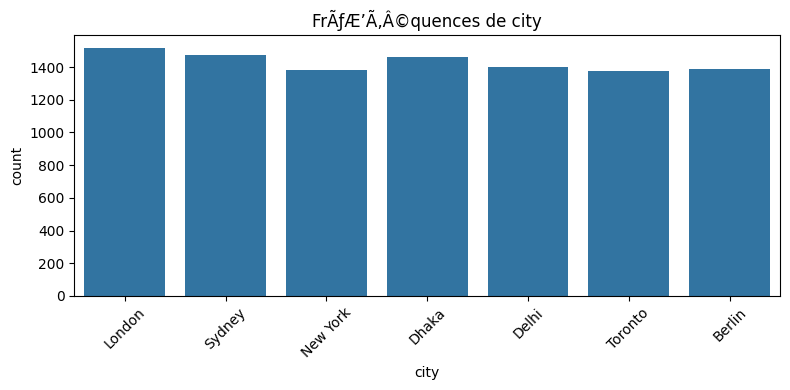

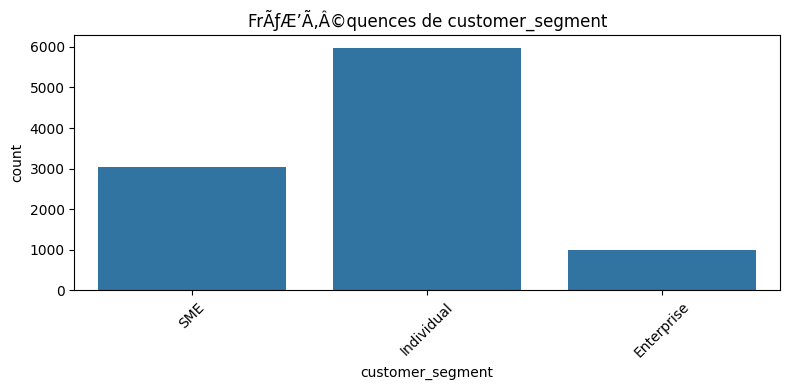

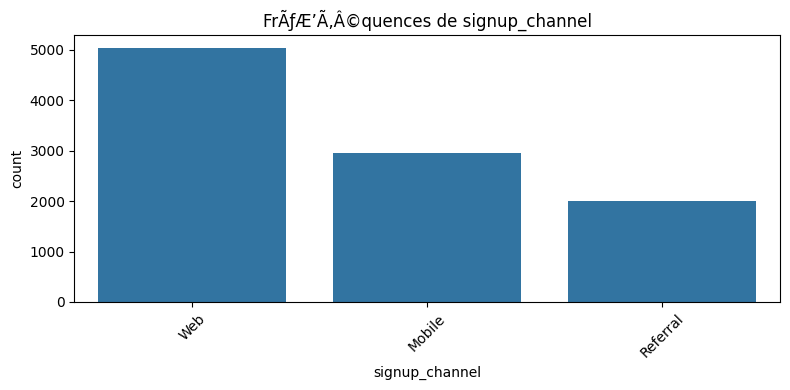

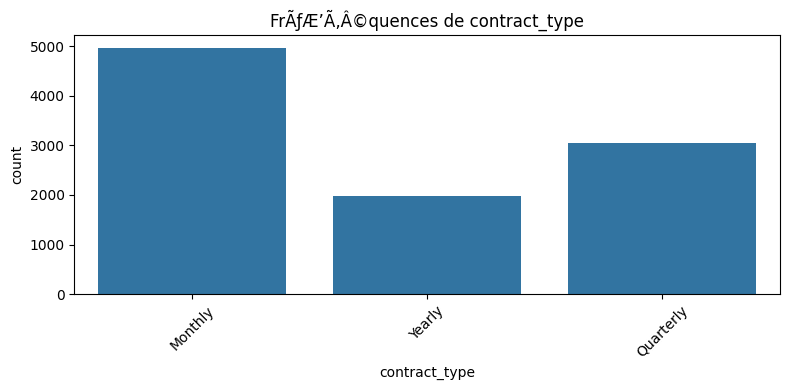

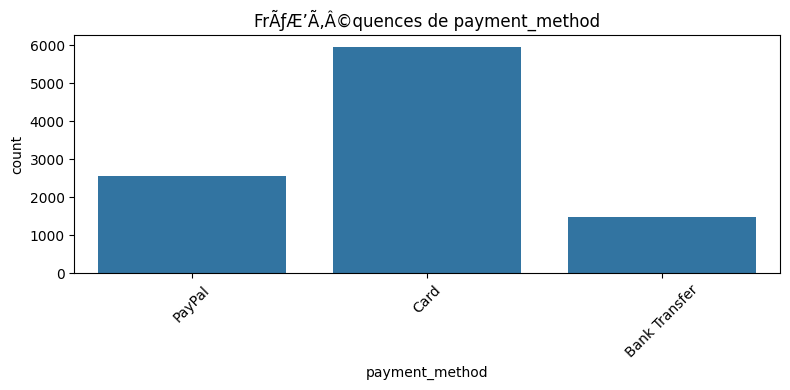

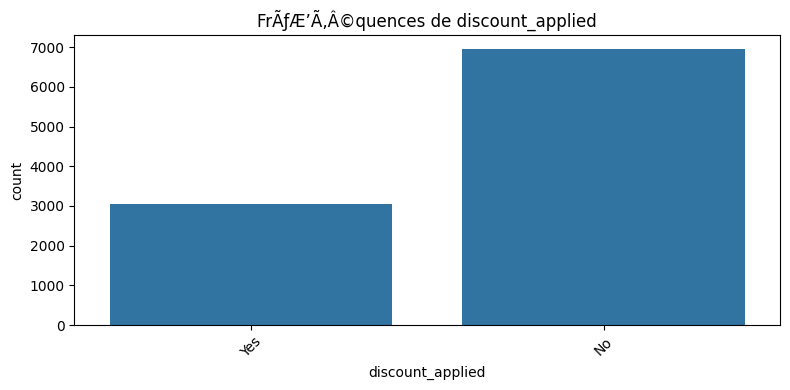

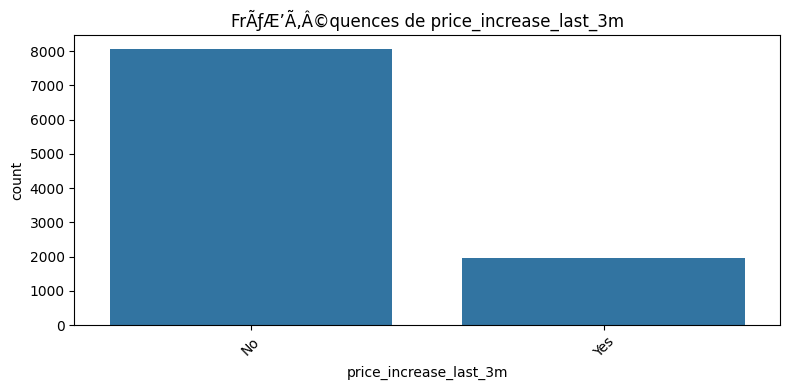

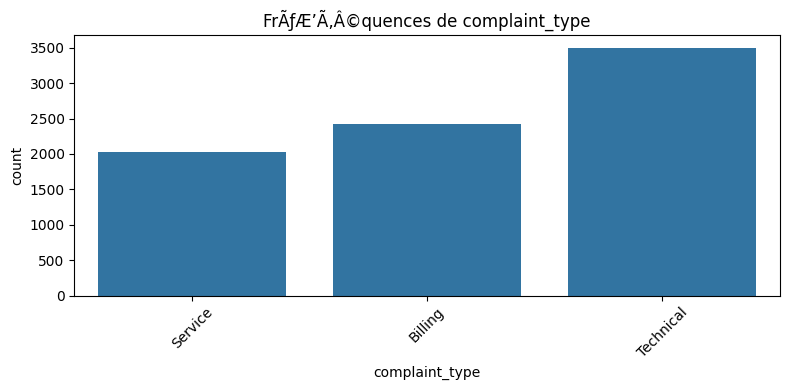

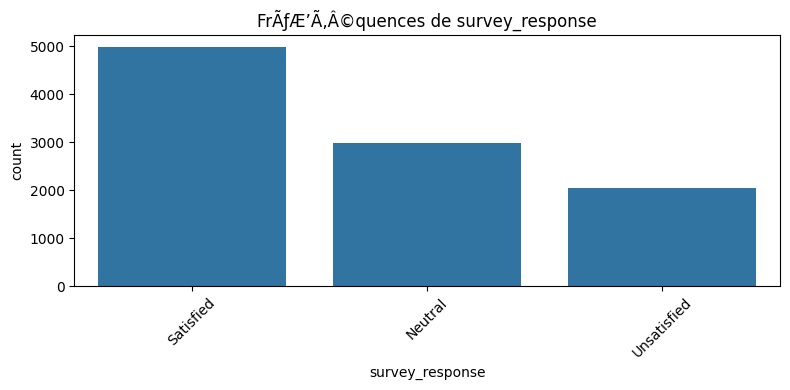

In [7]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=df[col])
    plt.title(f'FrÃƒÆ’Ã‚Â©quences de {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


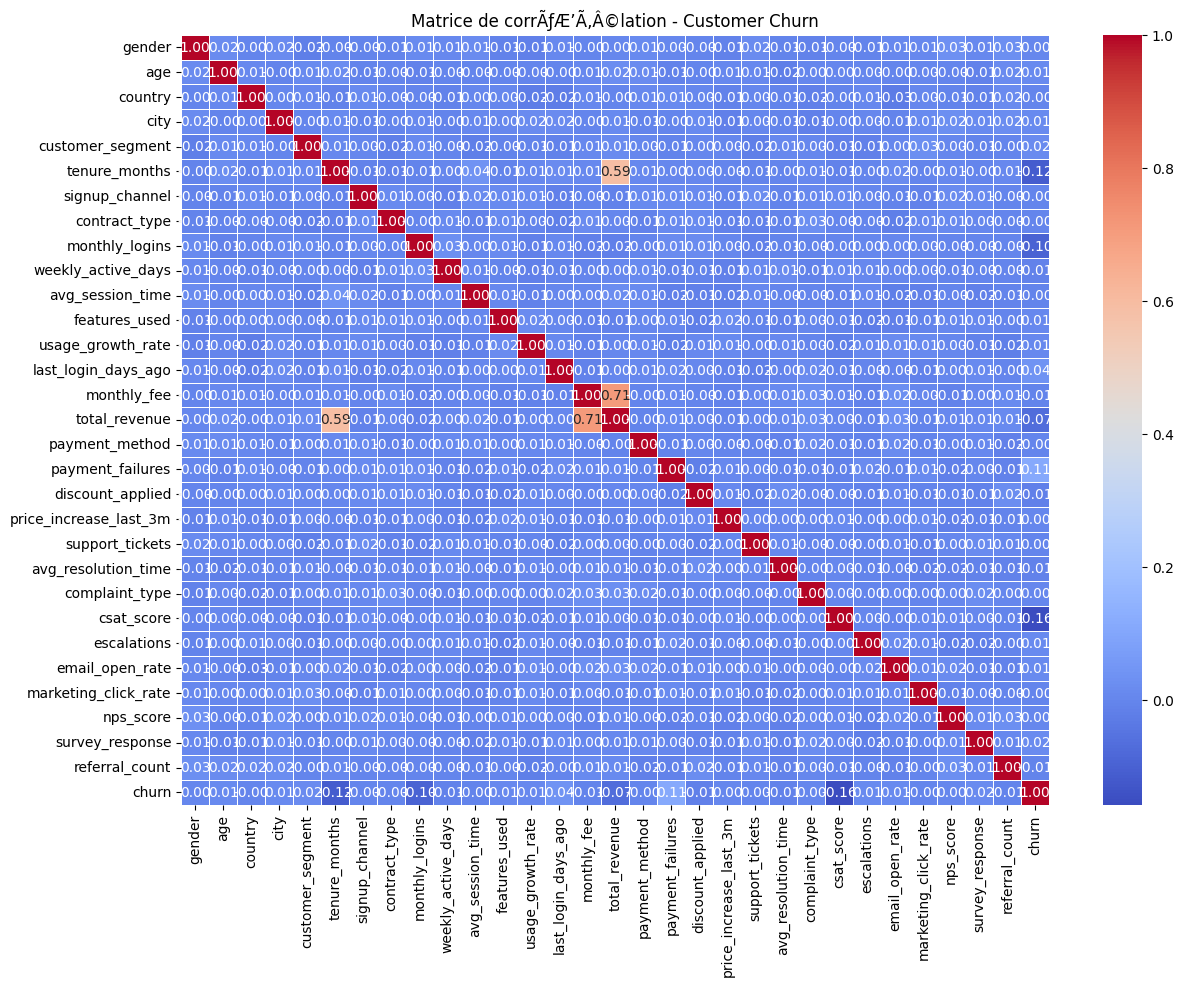

In [8]:
corr_matrix = df_corr.corr(numeric_only=True)

corr_matrix

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matrice de corrÃƒÆ’Ã‚Â©lation - Customer Churn")
plt.show()

# RÃƒÆ’Ã‚Â©sumÃƒÆ’Ã‚Â© : La matrice et la heatmap mettent en ÃƒÆ’Ã‚Â©vidence les corrÃƒÆ’Ã‚Â©lations entre variables.

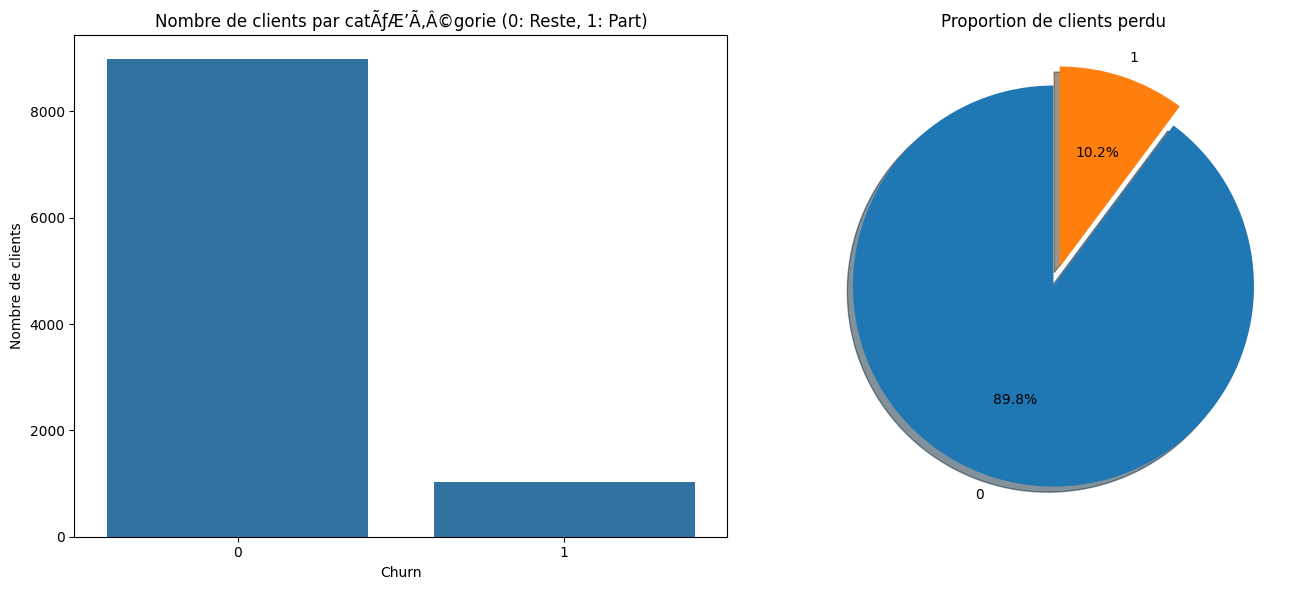

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(x='churn', data=df, ax=ax[0]) # graphique en barres (Countplot)
ax[0].set_title('Nombre de clients par catÃƒÆ’Ã‚Â©gorie (0: Reste, 1: Part)')
ax[0].set_xlabel('Churn')
ax[0].set_ylabel('Nombre de clients')

df['churn'].value_counts().plot.pie( #camembert (Pie chart) pour les proportions
    autopct='%1.1f%%', 
    ax=ax[1], 
    startangle=90, 
    explode=[0, 0.1], 
    shadow=True
)
ax[1].set_title('Proportion de clients perdu')
ax[1].set_ylabel('') #retire le label

plt.tight_layout()
plt.show()


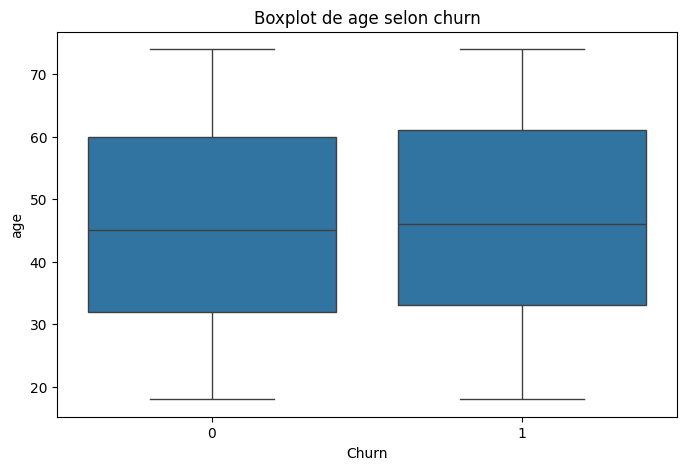

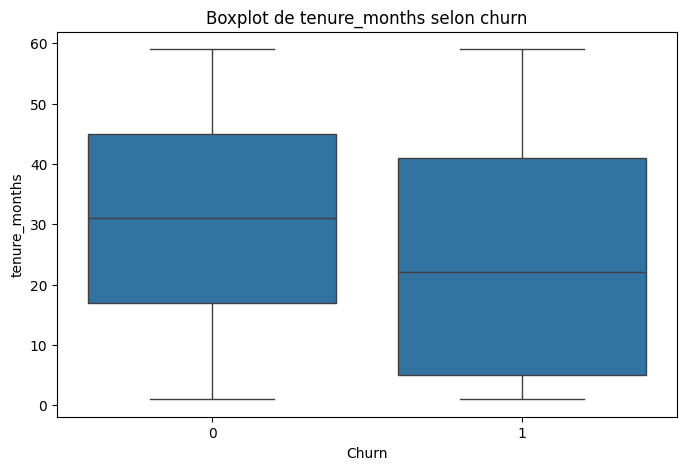

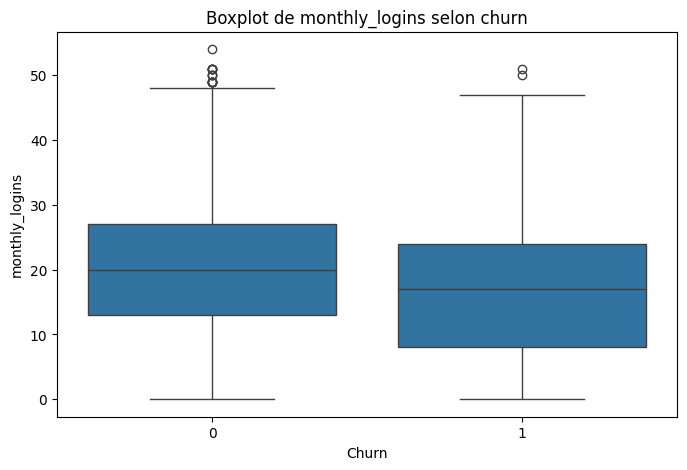

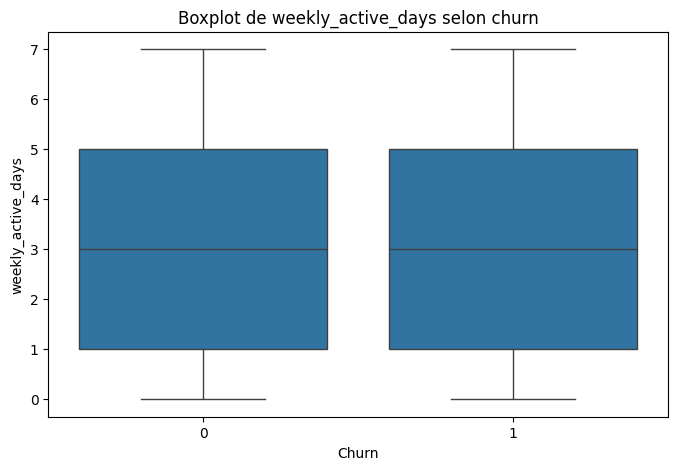

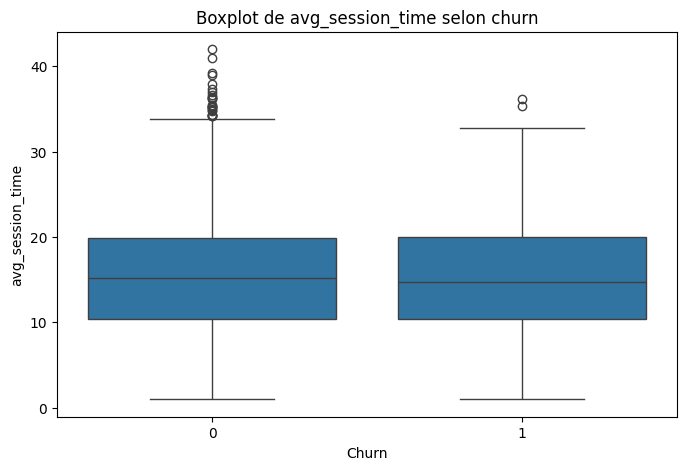

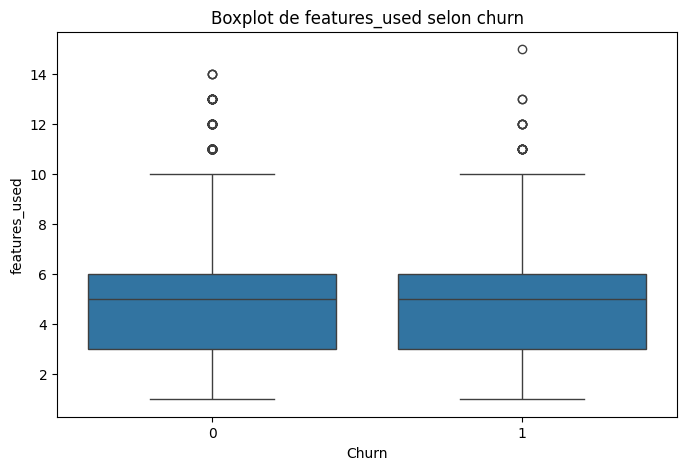

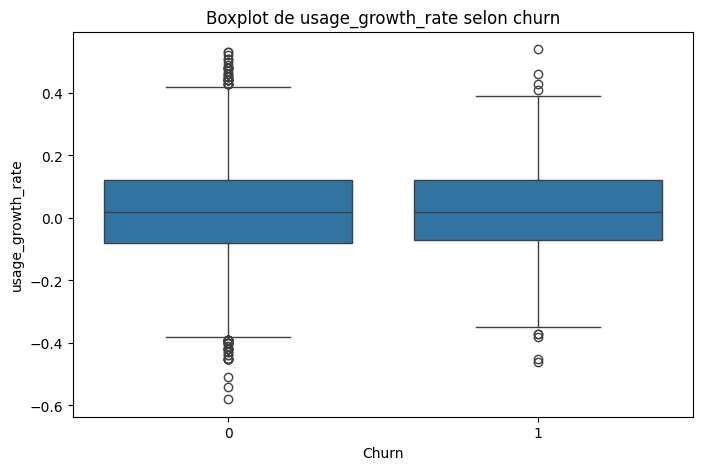

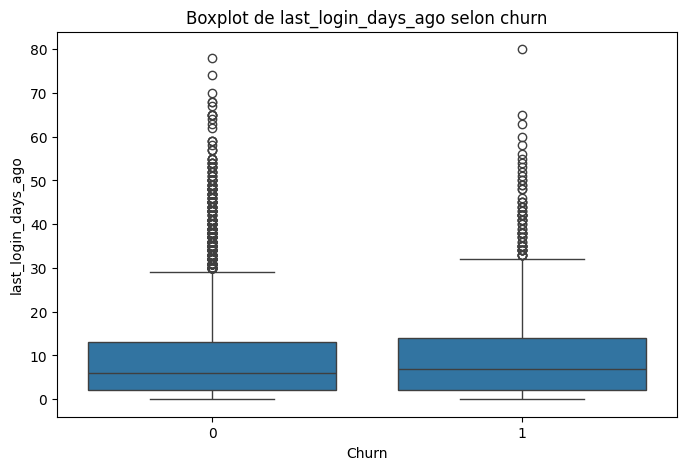

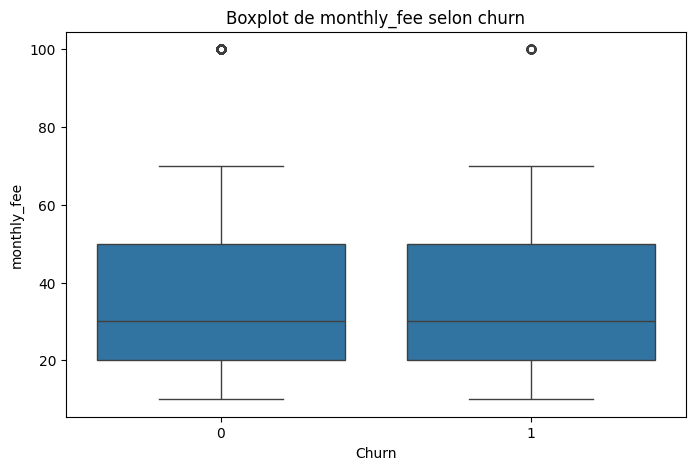

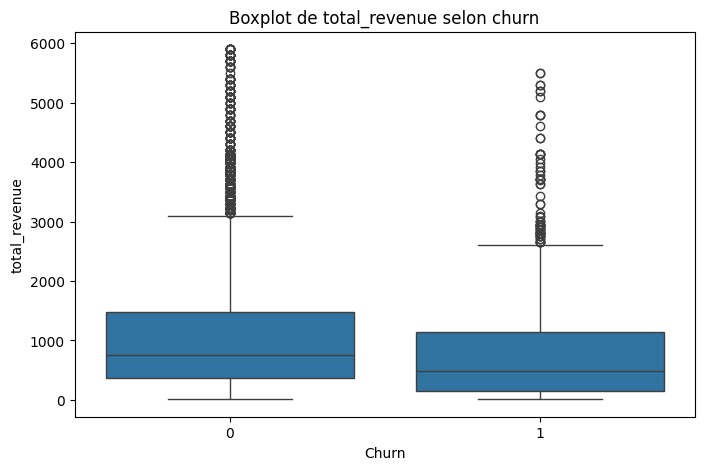

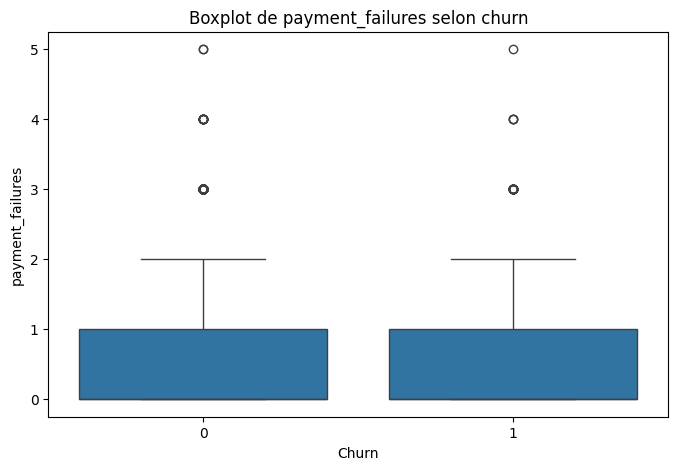

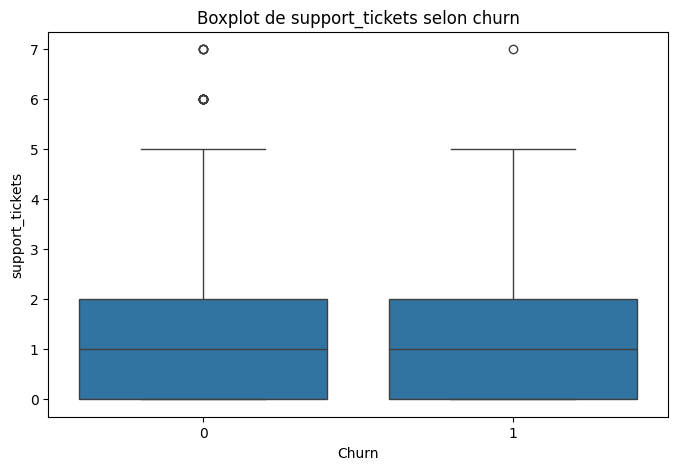

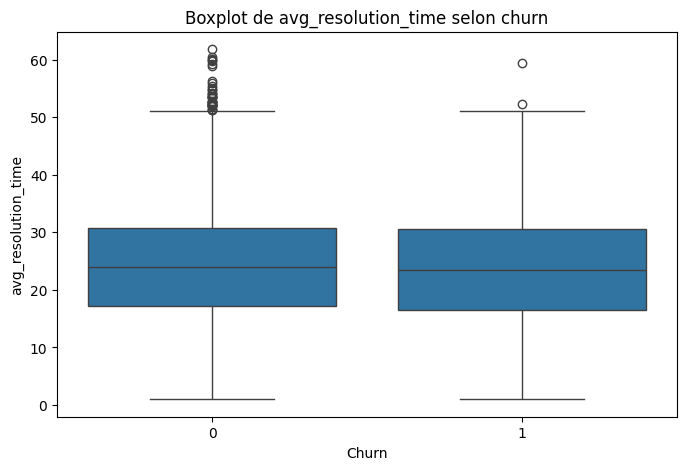

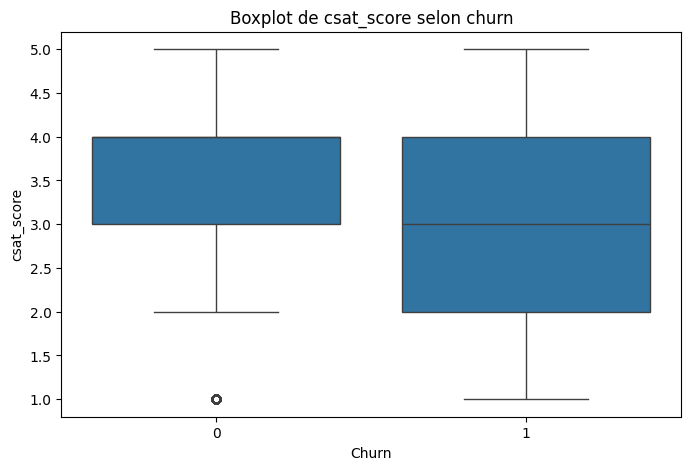

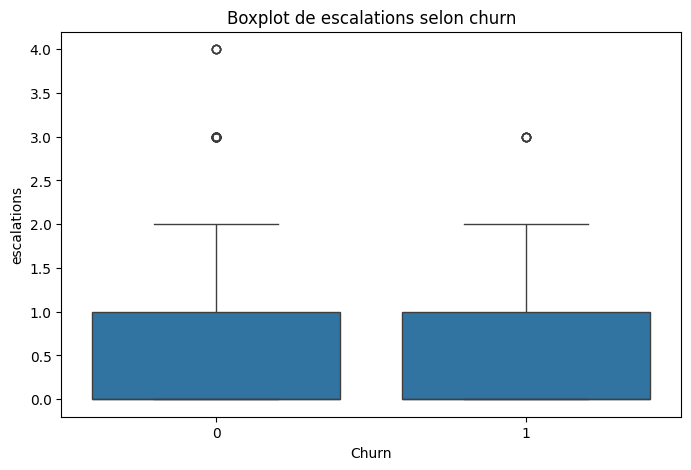

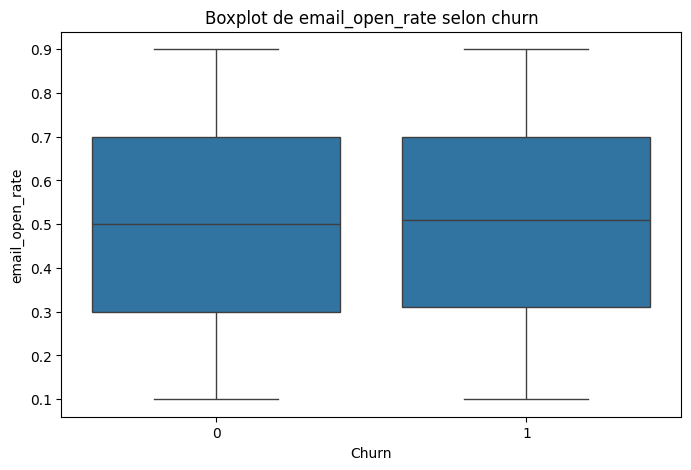

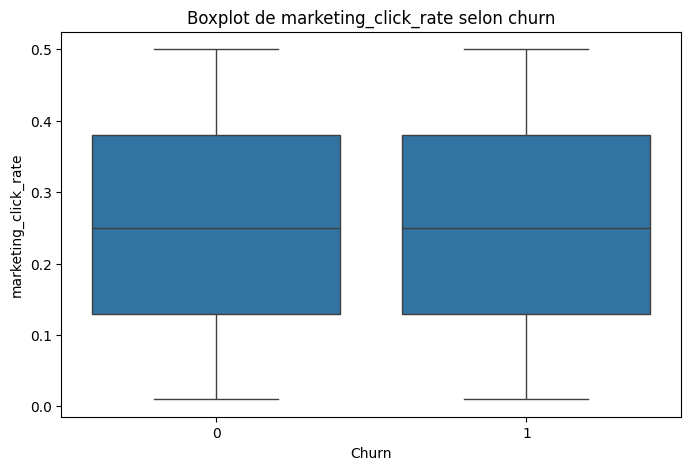

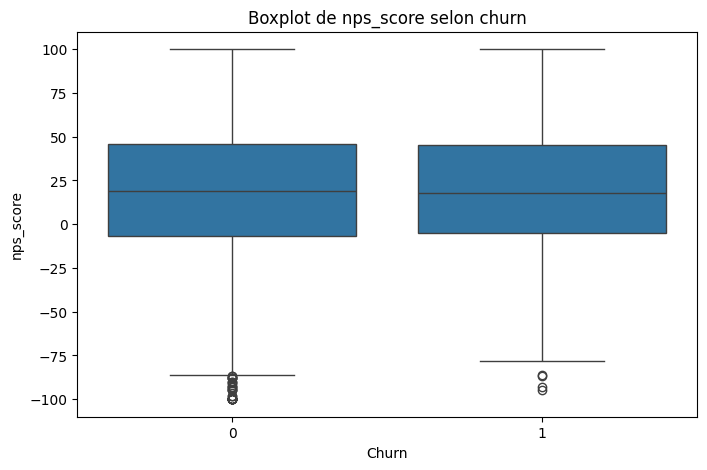

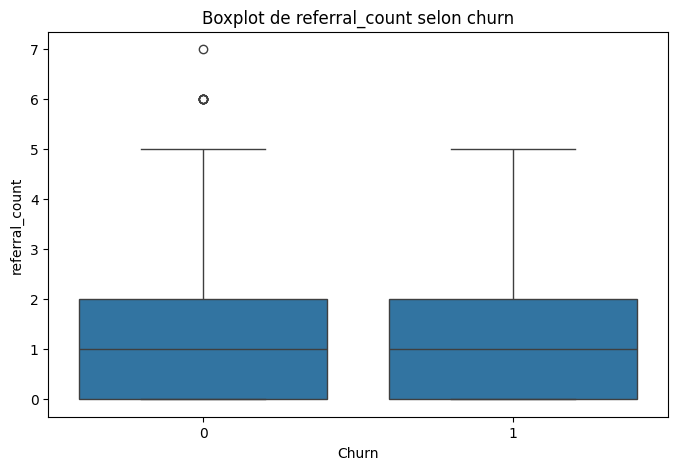

In [10]:
# Boxplots de toutes les variables numÃƒÆ’Ã‚Â©riques selon la variable cible churn
numerical_cols = df.select_dtypes(include=[np.number]).columns.drop('churn')
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='churn', y=col, data=df)
    plt.title(f'Boxplot de {col} selon churn')
    plt.xlabel('Churn')
    plt.ylabel(col)
    plt.show()


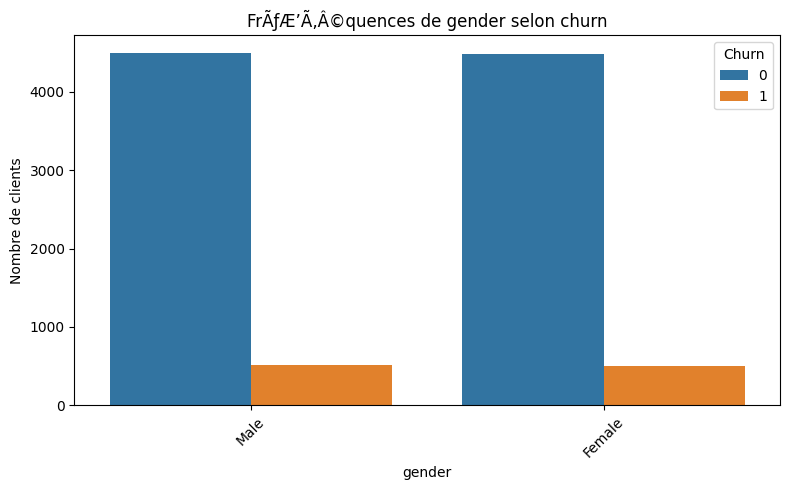

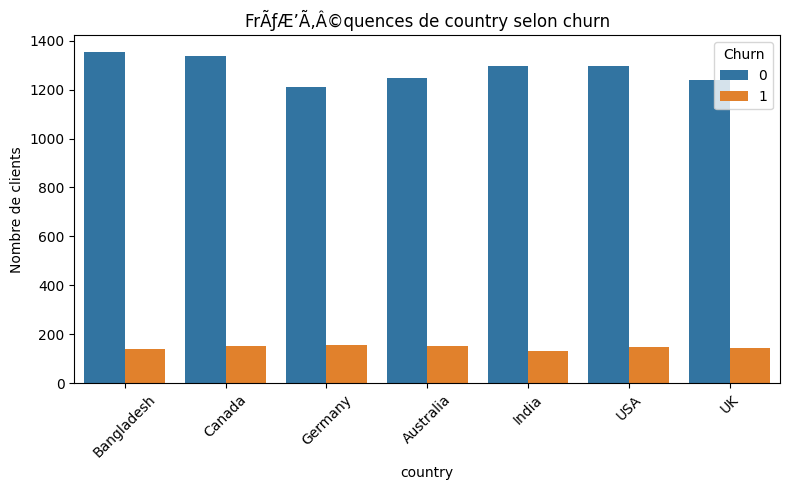

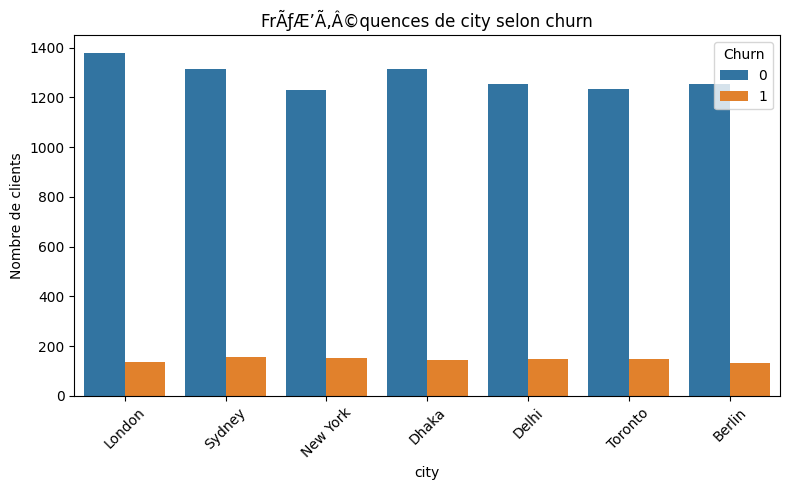

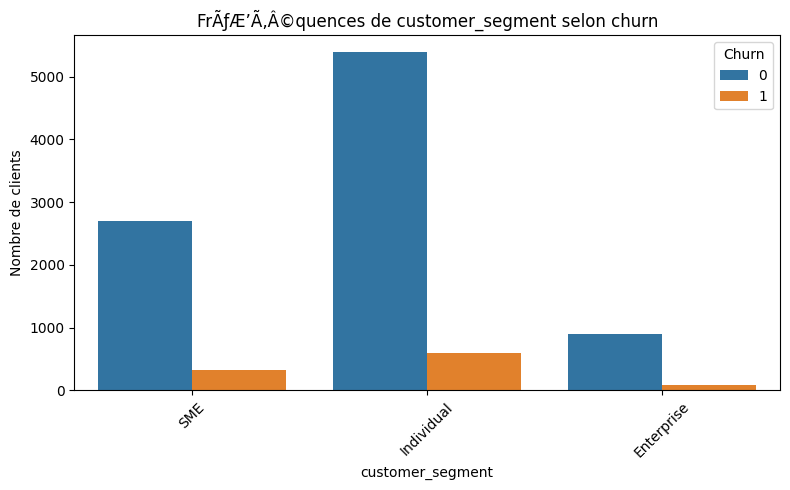

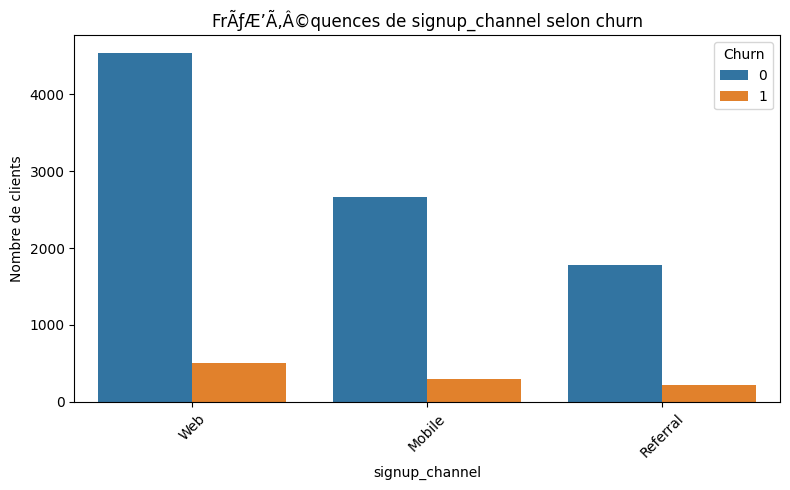

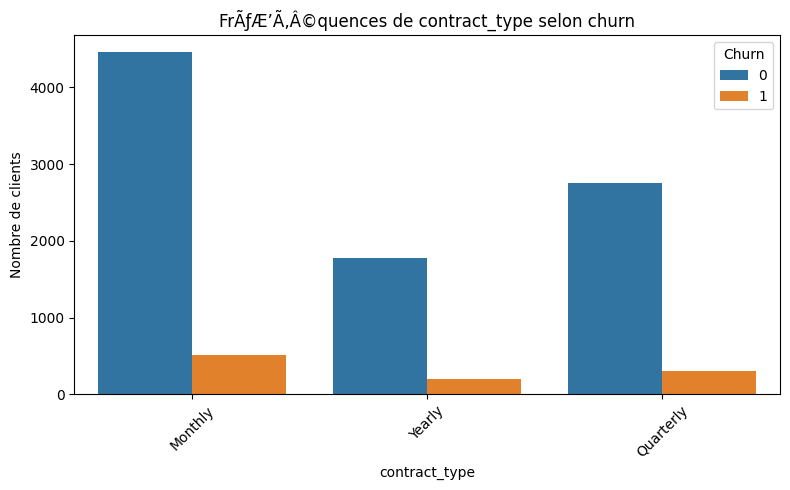

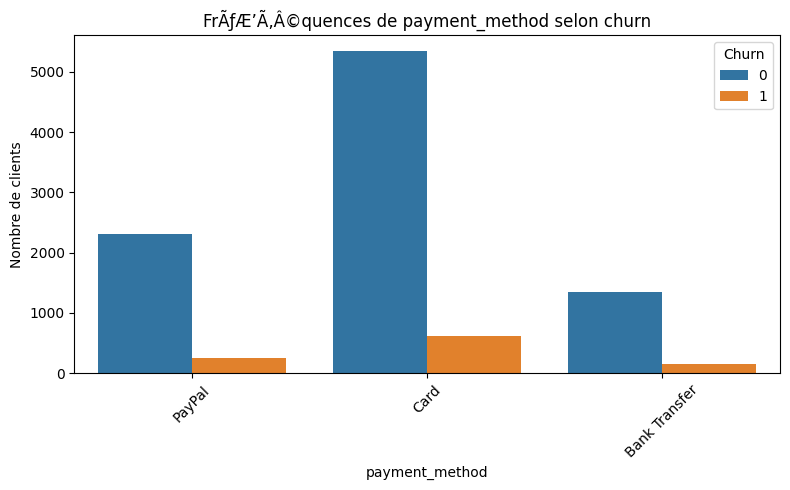

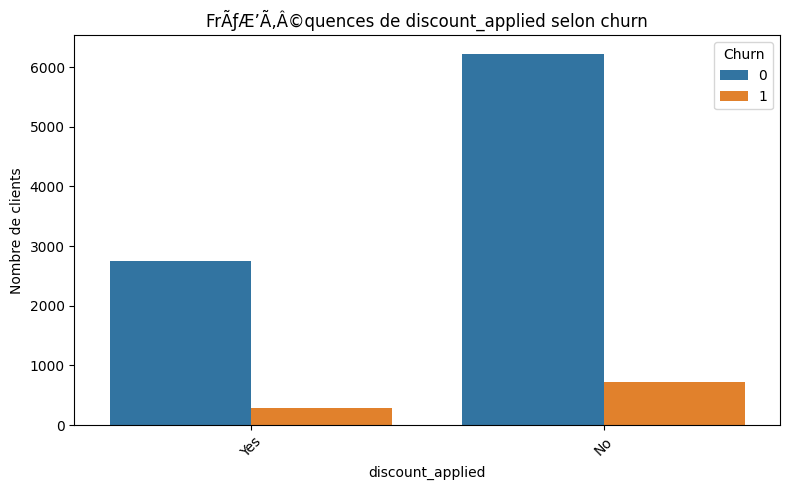

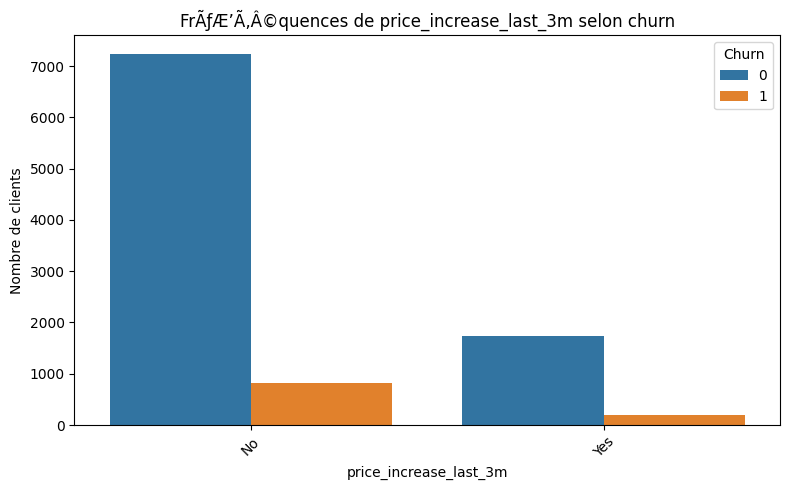

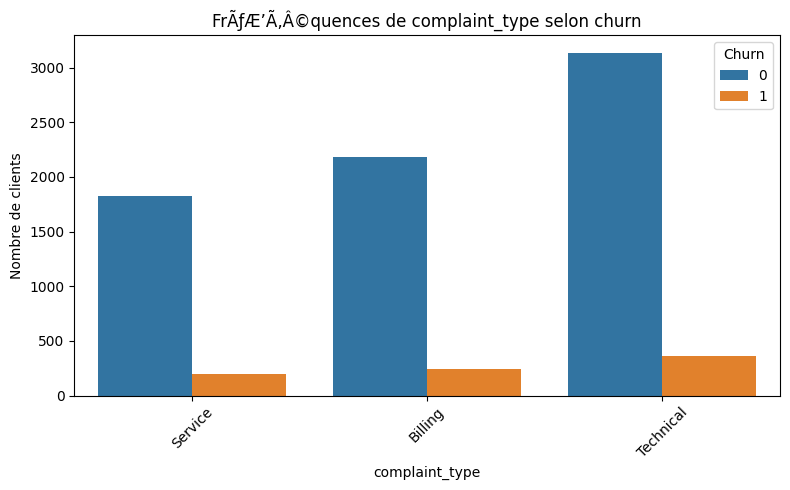

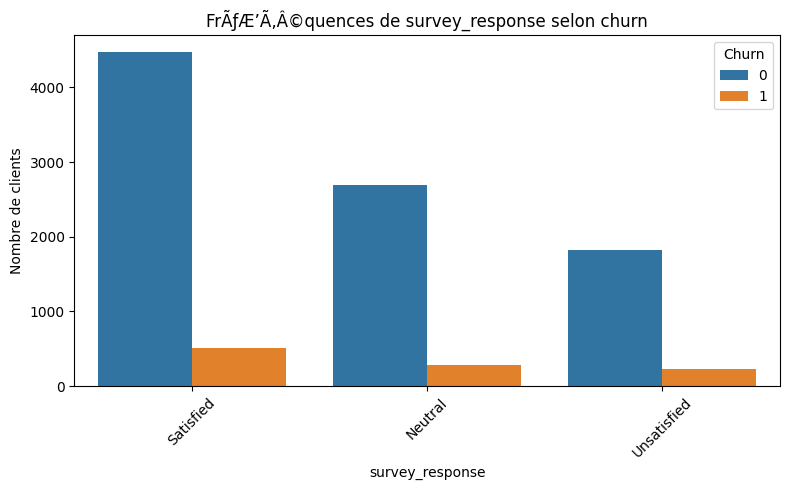

In [11]:
# Barplots des frÃƒÆ’Ã‚Â©quences pour les variables catÃƒÆ’Ã‚Â©gorielles selon la variable cible churn
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, hue='churn', data=df)
    plt.title(f'FrÃƒÆ’Ã‚Â©quences de {col} selon churn')
    plt.xlabel(col)
    plt.ylabel('Nombre de clients')
    plt.legend(title='Churn', loc='upper right')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## Phase 2 - Préparation des Données & Feature Engineering
Cette section prépare les features, gère le déséquilibre des classes et construit des pipelines selon le type de modèle.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

# Copie de travail pour le feature engineering
df_model = df.copy()

# RÃƒÆ’Ã‚Â©solution robuste des noms de colonnes (selon le dataset)
def pick_col(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    raise KeyError(f"Aucune de ces colonnes n'existe: {candidates}")

tenure_col = pick_col(df_model.columns, ['tenure', 'tenure_months'])
tickets_col = pick_col(df_model.columns, ['support_tickets'])
revenue_col = pick_col(df_model.columns, ['total_revenue'])
failures_col = pick_col(df_model.columns, ['payment_failures'])
target_col = pick_col(df_model.columns, ['churn'])

# Evite les divisions par 0 pour les nouvelles variables
tenure_safe = df_model[tenure_col].replace(0, np.nan)

df_model['tickets_per_tenure'] = (df_model[tickets_col] / tenure_safe).fillna(0)
df_model['revenue_per_month'] = (df_model[revenue_col] / tenure_safe).fillna(0)
df_model['payment_failure_rate'] = (df_model[failures_col] / tenure_safe).fillna(0)

X = df_model.drop(columns=[target_col])
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Colonnes utilisées -> tenure: {tenure_col}, tickets: {tickets_col}, revenue: {revenue_col}, failures: {failures_col}")
print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")
print('Répartition train (%):')
print((y_train.value_counts(normalize=True) * 100).round(2))

# Résumé : Les features métiers ont été créées et les données ont été séparées en train/test sans fuite d'information.

Colonnes utilisées -> tenure: tenure_months, tickets: support_tickets, revenue: total_revenue, failures: payment_failures
Train shape: (8000, 33) | Test shape: (2000, 33)
Répartition train (%):
churn
0    89.79
1    10.21
Name: proportion, dtype: float64


In [13]:
# Colonnes numériques et catégorielles (détectées sur le train uniquement)
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

# Préprocessing pour modèles sensibles à l'échelle (LogReg, MLP)
num_preprocess_scaled = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_preprocess = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_scaled = ColumnTransformer(transformers=[
    ('num', num_preprocess_scaled, num_features),
    ('cat', cat_preprocess, cat_features)
])

# Préprocessing pour modèles arbres (RF, XGBoost): pas de scaling
num_preprocess_tree = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor_tree = ColumnTransformer(transformers=[
    ('num', num_preprocess_tree, num_features),
    ('cat', cat_preprocess, cat_features)
])

print(f"Num features: {len(num_features)} | Cat features: {len(cat_features)}")

# Résumé : Deux preprocessings sont prêts, avec scaling pour LogReg/MLP et sans scaling pour les modèles d'arbres.

Num features: 22 | Cat features: 11


In [14]:
# Pipelines modèles avec gestion du déséquilibre via class_weight='balanced'
pipeline_logreg = Pipeline(steps=[
    ('preprocess', preprocessor_scaled),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

pipeline_mlp = Pipeline(steps=[
    ('preprocess', preprocessor_scaled),
    ('model', MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=400,
        random_state=42
    ))
])

pipeline_rf = Pipeline(steps=[
    ('preprocess', preprocessor_tree),
    ('model', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# XGBoost optionnel si installé
try:
    from xgboost import XGBClassifier
    neg, pos = y_train.value_counts()[0], y_train.value_counts()[1]
    scale_pos_weight = neg / pos if pos > 0 else 1.0

    pipeline_xgb = Pipeline(steps=[
        ('preprocess', preprocessor_tree),
        ('model', XGBClassifier(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42,
            scale_pos_weight=scale_pos_weight
        ))
    ])
    print('XGBoost disponible: pipeline_xgb crée.')
except Exception:
    pipeline_xgb = None
    print('XGBoost non installé: pipeline_xgb ignoré.')

# Résumé : Les pipelines de classification sont définis avec une stratégie de gestion du déséquilibre adaptée.

XGBoost disponible: pipeline_xgb crée.


In [15]:
from sklearn.metrics import classification_report, roc_auc_score

models = {
    'LogisticRegression': pipeline_logreg,
    'MLPClassifier': pipeline_mlp,
    'RandomForest': pipeline_rf,
}
if pipeline_xgb is not None:
    models['XGBoost'] = pipeline_xgb

results = []
for name, model in models.items():
    # Règle d'or respectée: fit sur train uniquement
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    results.append({'model': name, 'roc_auc': auc})

    print(f"\n===== {name} =====")
    print(f"ROC-AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred, digits=3, zero_division=0))

results_df = pd.DataFrame(results).sort_values('roc_auc', ascending=False)
display(results_df)

# Résumé : Chaque pipeline est entraîné sur le train puis évalué sur le test, sans fuite de données.


===== LogisticRegression =====
ROC-AUC: 0.7288
              precision    recall  f1-score   support

           0      0.945     0.679     0.790      1796
           1      0.187     0.652     0.291       204

    accuracy                          0.676      2000
   macro avg      0.566     0.665     0.541      2000
weighted avg      0.868     0.676     0.739      2000


===== MLPClassifier =====
ROC-AUC: 0.6684
              precision    recall  f1-score   support

           0      0.910     0.926     0.918      1796
           1      0.231     0.196     0.212       204

    accuracy                          0.852      2000
   macro avg      0.571     0.561     0.565      2000
weighted avg      0.841     0.852     0.846      2000


===== RandomForest =====
ROC-AUC: 0.8000
              precision    recall  f1-score   support

           0      0.898     1.000     0.946      1796
           1      0.000     0.000     0.000       204

    accuracy                          0.898      

,model,roc_auc
2,RandomForest,0.799994
3,XGBoost,0.770661
0,LogisticRegression,0.728760
1,MLPClassifier,0.668400


## Phase 3 - Benchmark Multi-Modeles`n
Objectif : comparer 4 familles de modeles (LogReg, Random Forest, Gradient Boosting type XGBoost/LightGBM, MLP deep learning), puis optimiser legerement les 2 meilleurs.`n

### 3.1 Protocole experimental
Nous fixons les graines aleatoires et definissons les metriques communes pour comparer les modeles de facon rigoureuse.

In [16]:
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from sklearn.ensemble import HistGradientBoostingClassifier
from scipy.stats import loguniform, randint, uniform

import tensorflow as tf
from tensorflow import keras

np.random.seed(42)
tf.random.set_seed(42)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def test_metrics_from_proba(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'test_roc_auc': roc_auc_score(y_true, y_proba),
        'test_precision': precision_score(y_true, y_pred, zero_division=0),
        'test_recall': recall_score(y_true, y_pred, zero_division=0),
        'test_f1': f1_score(y_true, y_pred, zero_division=0),
    }

# Resume : Le protocole de validation et les metriques d evaluation sont prets.

### 3.2 Definition des modeles
Nous construisons une baseline interpretable (LogReg), un ensemble robuste (Random Forest), un boosting performant et un MLP pour capter des interactions complexes.

In [17]:
# 1) Regression Logistique
model_logreg = Pipeline(steps=[
    ('preprocess', preprocessor_scaled),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# 2) Random Forest
model_rf = Pipeline(steps=[
    ('preprocess', preprocessor_tree),
    ('model', RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=42, n_jobs=-1))
])

# 3) Gradient Boosting (XGBoost/LightGBM si dispo, sinon fallback)
boost_model_name = None
try:
    from xgboost import XGBClassifier
    neg, pos = y_train.value_counts()[0], y_train.value_counts()[1]
    scale_pos_weight = neg / pos if pos > 0 else 1.0
    model_boost = Pipeline(steps=[
        ('preprocess', preprocessor_tree),
        ('model', XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=6, subsample=0.9, colsample_bytree=0.9, objective='binary:logistic', eval_metric='logloss', random_state=42, scale_pos_weight=scale_pos_weight))
    ])
    boost_model_name = 'XGBoost'
except Exception:
    try:
        from lightgbm import LGBMClassifier
        model_boost = Pipeline(steps=[
            ('preprocess', preprocessor_tree),
            ('model', LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=31, class_weight='balanced', random_state=42))
        ])
        boost_model_name = 'LightGBM'
    except Exception:
        model_boost = Pipeline(steps=[
            ('preprocess', preprocessor_tree),
            ('model', HistGradientBoostingClassifier(learning_rate=0.05, max_depth=8, max_iter=300, random_state=42))
        ])
        boost_model_name = 'HistGradientBoosting (fallback)'

print(f'Modele boosting retenu: {boost_model_name}')

# 4) MLP (Keras)
def build_keras_mlp(input_dim, lr=1e-3, dropout=0.2):
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss='binary_crossentropy', metrics=[keras.metrics.AUC(name='auc')])
    return model

counts = y_train.value_counts()
n_total = len(y_train)
class_weight = {0: n_total / (2 * counts.get(0, 1)), 1: n_total / (2 * counts.get(1, 1))}

model_registry = {
    'LogisticRegression': model_logreg,
    'RandomForest': model_rf,
    boost_model_name: model_boost,
}

# Resume : Les 4 familles de modeles et leurs parametres de base sont definis.

Modele boosting retenu: XGBoost


### 3.3 Benchmark train/test et validation croisee
Chaque modele est evalue sur le jeu de test et via StratifiedKFold (k=5) pour estimer sa robustesse.

In [18]:
benchmark_rows = []

# Benchmark des modeles sklearn
for model_name, model in model_registry.items():
    cv = cross_validate(model, X_train, y_train, cv=skf, scoring='roc_auc', n_jobs=-1)
    model.fit(X_train, y_train)
    y_proba_test = model.predict_proba(X_test)[:, 1]
    m = test_metrics_from_proba(y_test, y_proba_test)
    benchmark_rows.append({
        'model': model_name,
        'cv_roc_auc_mean': np.mean(cv['test_score']),
        'cv_roc_auc_std': np.std(cv['test_score']),
        **m
    })

# Benchmark MLP Keras (train/test + CV manuelle)
mlp_preprocessor = clone(preprocessor_scaled)
X_train_mlp = mlp_preprocessor.fit_transform(X_train)
X_test_mlp = mlp_preprocessor.transform(X_test)
if hasattr(X_train_mlp, 'toarray'):
    X_train_mlp = X_train_mlp.toarray()
if hasattr(X_test_mlp, 'toarray'):
    X_test_mlp = X_test_mlp.toarray()

keras_model = build_keras_mlp(X_train_mlp.shape[1])
keras_model.fit(
    X_train_mlp,
    y_train.values,
    validation_split=0.2,
    epochs=25,
    batch_size=128,
    verbose=0,
    class_weight=class_weight,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=3, restore_best_weights=True)]
)
y_proba_keras = keras_model.predict(X_test_mlp, verbose=0).ravel()
keras_metrics = test_metrics_from_proba(y_test.values, y_proba_keras)

keras_cv_scores = []
for tr_idx, val_idx in skf.split(X_train, y_train):
    X_tr_fold = X_train.iloc[tr_idx]
    X_val_fold = X_train.iloc[val_idx]
    y_tr_fold = y_train.iloc[tr_idx]
    y_val_fold = y_train.iloc[val_idx]

    fold_pre = clone(preprocessor_scaled)
    X_tr_proc = fold_pre.fit_transform(X_tr_fold)
    X_val_proc = fold_pre.transform(X_val_fold)

    if hasattr(X_tr_proc, 'toarray'):
        X_tr_proc = X_tr_proc.toarray()
    if hasattr(X_val_proc, 'toarray'):
        X_val_proc = X_val_proc.toarray()

    fold_model = build_keras_mlp(X_tr_proc.shape[1])
    fold_model.fit(
        X_tr_proc,
        y_tr_fold.values,
        epochs=12,
        batch_size=128,
        verbose=0,
        class_weight=class_weight,
        callbacks=[keras.callbacks.EarlyStopping(monitor='loss', patience=2, restore_best_weights=True)]
    )
    y_val_proba = fold_model.predict(X_val_proc, verbose=0).ravel()
    keras_cv_scores.append(roc_auc_score(y_val_fold.values, y_val_proba))

benchmark_rows.append({
    'model': 'MLP (Keras)',
    'cv_roc_auc_mean': float(np.mean(keras_cv_scores)),
    'cv_roc_auc_std': float(np.std(keras_cv_scores)),
    **keras_metrics
})

benchmark_df = pd.DataFrame(benchmark_rows).sort_values('test_roc_auc', ascending=False).reset_index(drop=True)
display(benchmark_df)

# Resume : Le benchmark compare performance pure et robustesse des modeles.

,model,cv_roc_auc_mean,cv_roc_auc_std,test_roc_auc,test_precision,test_recall,test_f1
0,RandomForest,0.797501,0.013887,0.799804,0.000000,0.000000,0.000000
1,XGBoost,0.767840,0.020136,0.770661,0.233503,0.225490,0.229426
2,MLP (Keras),0.736711,0.019000,0.743310,0.219430,0.642157,0.327091
3,LogisticRegression,0.730312,0.017107,0.728760,0.187324,0.651961,0.291028


### 3.4 Optimisation legere des deux meilleurs modeles
Nous appliquons un RandomizedSearchCV sur les deux meilleurs modeles sklearn du benchmark pour affiner les hyperparametres.

In [19]:
search_spaces = {
    'LogisticRegression': {
        'model__C': loguniform(1e-3, 1e2),
        'model__solver': ['lbfgs', 'liblinear'],
        'model__penalty': ['l2'],
    },
    'RandomForest': {
        'model__n_estimators': randint(200, 700),
        'model__max_depth': [None, 8, 12, 16, 24],
        'model__min_samples_split': randint(2, 20),
        'model__min_samples_leaf': randint(1, 10),
        'model__max_features': ['sqrt', 'log2', None],
    },
    'XGBoost': {
        'model__n_estimators': randint(200, 700),
        'model__max_depth': randint(3, 10),
        'model__learning_rate': loguniform(1e-3, 2e-1),
        'model__subsample': uniform(0.6, 0.4),
        'model__colsample_bytree': uniform(0.6, 0.4),
    },
    'LightGBM': {
        'model__n_estimators': randint(200, 700),
        'model__learning_rate': loguniform(1e-3, 2e-1),
        'model__num_leaves': randint(16, 128),
        'model__min_child_samples': randint(5, 60),
        'model__subsample': uniform(0.6, 0.4),
        'model__colsample_bytree': uniform(0.6, 0.4),
    },
    'HistGradientBoosting (fallback)': {
        'model__learning_rate': loguniform(1e-3, 2e-1),
        'model__max_depth': randint(3, 12),
        'model__max_iter': randint(150, 500),
        'model__min_samples_leaf': randint(20, 120),
    },
}

eligible_for_tuning = benchmark_df[benchmark_df['model'].isin(model_registry.keys())].copy()
top2_models = eligible_for_tuning.head(2)['model'].tolist()
print('Top 2 modeles a optimiser :', top2_models)

tuning_rows = []
best_estimators = {}

for model_name in top2_models:
    base_model = model_registry[model_name]
    params = search_spaces[model_name]

    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=params,
        n_iter=12,
        scoring='roc_auc',
        cv=skf,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    best_estimators[model_name] = best_model

    y_proba_test = best_model.predict_proba(X_test)[:, 1]
    tuned_metrics = test_metrics_from_proba(y_test, y_proba_test)

    tuning_rows.append({
        'model': model_name,
        'best_cv_roc_auc': search.best_score_,
        'best_params': search.best_params_,
        **tuned_metrics
    })

tuning_df = pd.DataFrame(tuning_rows).sort_values('test_roc_auc', ascending=False).reset_index(drop=True)
display(tuning_df)

# Resume : Le tuning permet de securiser le choix final du modele.

Top 2 modeles a optimiser : ['RandomForest', 'XGBoost']
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits


,model,best_cv_roc_auc,best_params,test_roc_auc,test_precision,test_recall,test_f1
0,XGBoost,0.808106,{'model__colsample_bytree': 0.8446612641953124...,0.806644,0.248756,0.735294,0.371747
1,RandomForest,0.804699,"{'model__max_depth': 16, 'model__max_features'...",0.803499,0.343096,0.401961,0.370203
